# Jupyter Notebook 1. EDA и подготовка данных

**Стажёр:** [Парцей Петр]

На входе — сырые данные из таблиц трёх видов: `listings`, `calendar`, `reviews`.
На выходе вы должны создать датасет для обучения модели.

## 1. Подключение библиотек

In [ ]:
!pip install langdetect phik python-dotenv -q

In [1]:
# Здесь все необходимые импорты

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import psycopg2
import phik
from phik.report import plot_correlation_matrix
import ast
from langdetect import DetectorFactory, detect
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
import joblib

In [2]:
# Показывать все строки
pd.set_option('display.max_rows', 20)

# Показывать все столбцы
pd.set_option('display.max_columns', None)

# Показывать полный текст в ячейках (без обрезки строк)
pd.set_option('display.max_colwidth', 20)


Фиксируем `random_state` для воспроизводимости результатов.

In [3]:
RANDOM_STATE = 42

## 2. Загрузка и первичный осмотр данных

Загрузите таблицы. Для каждой зафиксируйте размер, типы данных, пропуски и ключевые наблюдения.

На прошлом этапе первичного знакомства с данными и составления плана проекта было установлено, что для дальнейшей работы необходимы только таблицы `listings`. В них есть все необходимые данные для создания целевой переменной и построения моделей.

Таблицы `calendars` не содержат ни какой полезной информации. Столбцы с ценами в них абсолютно пустые и не позволяют хоть как-то дополнить таблицы `listings`. Данные о доступности жилья уже есть в агрегированном виде в таблицах `listings`, как и минимальные и максимальные сроки аренды.

Таблицы `reviews` из полезного могут дат только даты отзывов, но они также уже присутствуют в таблицах `listings`. Тексты комментариев для построения модели не нужны.

В целом, таблицы `calendars` и `reviews` содержат только исторические данные, от которых следует избавится, чтобы не создавать утечки данных. Модель должна предсказывать спрос на объявление об аренде основываясь только на характеристиках самого объявления, чтобы научиться определять новые и перспективные. Не должно быть ни каких реакций пользователей, отзывов и оценок. По этой же причине из таблиц `listings` следует удалить 27 столбцов с историческими данными, оставив только те, которые нужны для создания целевой переменной. Столбцы с данными о доступности жилья `availability_`, `has_availability` и `estimated_occupancy_l365d` подскажут модели, что жильё пользуется спросом. Все столбцы содержащие `reviews` создадут утечку данных и внесут шум, который не позволит модели определять новые качественные объявления. Только два признака "numeric_of_reviews" и "numeric_of_reviews_l30d" пока останутся в датасете, они помогут отфильтровать слишком старые и слишком новые объявления. Выручка за последний год `estimated_revenue_l365d` навредит, отделяя новые объявления без истории от старых и успешных. Столбцы с информацией о хозяине объявления `host_` и `calculated_host_` тоже дадут модели исторические сведения. Стоит оставит только столбцы с верификацией хоста и, возможно, с его количеством объявлений `host_listings_count`, после проверки на утечку данных. Колонка `neighbourhood_group_cleansed` полностью пустая в восьми городах, пользы для модели от неё не будет.


In [5]:
# Загружаем переменные из файла .env, в той же папке, что и тетрадка
load_dotenv(dotenv_path=".env")

# Безопасно собираем конфигурацию, используя переменные окружения
db_config = {
    'user': os.getenv("DB_USER"),
    'pwd': os.getenv("DB_PASSWORD"),
    'host': 'rc1d-pdq3kahro9enkfir.mdb.yandexcloud.net',
    'port': 6432,
    'db': os.getenv("DB_NAME")}

In [6]:
# Форматирование строки подключения
connection_string = 'postgresql://{user}:{pwd}@{host}:{port}/{db}'.format(**db_config)
engine = create_engine(connection_string)

Загружаем таблицы без лишних колонок.

In [7]:
cities = ["amsterdam",
    "chicago",
    "la",
    "london",
    "lyon",
    "munich",
    "nyc",
    "paris",
    "toronto",
    "vienna"]


columns_to_exclude = ["availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "availability_eoy",
    "has_availability",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
    "numeric_of_reviews_ly",
    "reviews_per_month",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "host_since",
    "host_response_time",
    "host_response_rate",
    "host_acceptance_rate",
    "host_is_superhost",
    "host_total_listings_count",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "neighbourhood_group_cleansed"]


for city in cities:

    table_name = f"{city}_listings"

    query = """
    SELECT *
    FROM final_project.{table_name}
    """.format(table_name=table_name)

    # Получаем названия всех столбцов таблицы
    columns_query = """
    SELECT column_name
    FROM information_schema.columns
    WHERE table_schema = 'final_project'
      AND table_name = %(table_name)s
    ORDER BY ordinal_position
    """

    columns = pd.read_sql(
        columns_query,
        engine,
        params={"table_name": table_name}
    )["column_name"].tolist()

    # Оставляем только нужные столбцы
    columns_to_load = [
        column
        for column in columns
        if column not in columns_to_exclude
    ]

    # Формируем SELECT только из нужных столбцов
    select_columns = ", ".join(
        f'"{column}"'
        for column in columns_to_load
    )

    query = f"""
    SELECT {select_columns}
    FROM final_project."{table_name}"
    """

    df = pd.read_sql(query, engine)

    globals()[f"df_{city}"] = df

    print(f"{city}: {df.shape}")

amsterdam: (20648, 37)
chicago: (17264, 37)
la: (91427, 37)
london: (193341, 37)
lyon: (19312, 37)
munich: (15409, 37)
nyc: (72597, 37)
paris: (165785, 37)
toronto: (37244, 37)
vienna: (28398, 37)


In [4]:
# !!!ЭТО ЗАГРУЗКА ФАЙЛОВ из ПАМЯТИ КОМПА!!! ПЕРЕД СДАЧЕЙ НАДО УДАЛИТЬ!!!!!!!!!!!!!!
cities = ["amsterdam",
    "chicago",
    "la",
    "london",
    "lyon",
    "munich",
    "nyc",
    "paris",
    "toronto",
    "vienna"]

for city in cities:
    
    df = pd.read_parquet(
        f"data/{city}_listings.parquet"
    )
    
    globals()[f"df_{city}"] = df

Таблицы успешно загружены. Их размеры соответсвуют тем, что были установлены при первичном знакомстве с данными.

Создаём словарь, для удобства работы с таблицами.

In [5]:
dfs = {"amsterdam": df_amsterdam,
    "chicago": df_chicago,
    "la": df_la,
    "london": df_london,
    "lyon": df_lyon,
    "munich": df_munich,
    "nyc": df_nyc,
    "paris": df_paris,
    "toronto": df_toronto,
    "vienna": df_vienna}

Выводим общую информацию по всем таблицам:

In [6]:
for table_name, df in dfs.items():
    print(f"=== Информация о таблице: {table_name} ===")
    df.info()
    print("\n" + "="*40 + "\n")

=== Информация о таблице: amsterdam ===
<class 'pandas.DataFrame'>
RangeIndex: 20648 entries, 0 to 20647
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       20648 non-null  float64
 1   source                   20648 non-null  str    
 2   name                     20648 non-null  str    
 3   description              19991 non-null  str    
 4   neighborhood_overview    10450 non-null  str    
 5   host_id                  20648 non-null  float64
 6   host_listings_count      20641 non-null  float64
 7   host_verifications       20641 non-null  str    
 8   host_has_profile_pic     20641 non-null  object 
 9   host_identity_verified   20641 non-null  object 
 10  neighbourhood_cleansed   20648 non-null  str    
 11  latitude                 20648 non-null  float64
 12  longitude                20648 non-null  float64
 13  property_type            20648 non-null  str   

Таблицы успешно загружены. Их размеры и типы данных соответствуют ожидаемым. Видно много пропущенных значений.

Проверяем количество пропусков в ключемыв колонках, по которым будет создаваться целевая переменная:

In [7]:
# Ключевые признаки
target_columns = ['price', 'review_scores_rating', 'numeric_of_reviews_ltm']

# Собираем пропуски в словарь: {город: [пропуски_1, пропуски_2, пропуски_3]}
missing_dict = {city: [df[col].isna().sum() for col in target_columns] for city, df in dfs.items()}

# Создаем итоговую таблицу
df_missing_matrix = pd.DataFrame(missing_dict, index=target_columns)

# Выводим результат
df_missing_matrix

,amsterdam,chicago,la,london,lyon,munich,nyc,paris,toronto,vienna
price,8453,1758,54608,68696,8571,5080,33234,111822,21435,7609
review_scores_rating,2067,3466,24676,49145,3570,3190,22726,37418,8084,4770
numeric_of_reviews_ltm,0,0,0,0,0,0,0,0,0,0


Пропуски в столбцах 'price' и 'review_scores_rating' востановить с помощью аппроксимации нельзя, они слишком уникальные. Также, это приведёт к утечке данных. Такие строки лучше удалить. Кроме того, объявления без отзывов, скорее всего, самые свежие и ещё не успели набрать исторических данных, они будут вносить сильный шум, не давая модели выявить закономерности. Такие объявления модель не должна видеть.

In [8]:
# Удаляем строки с пропусками в указанных столбцах для каждого города
for city_name, df in dfs.items():
    dfs[city_name] = df.dropna(subset=['price', 'review_scores_rating'])

# Проверяем результат
missing_dict = {city: [df[col].isna().sum() for col in target_columns] for city, df in dfs.items()}
df_missing_matrix = pd.DataFrame(missing_dict, index=target_columns)
df_missing_matrix

,amsterdam,chicago,la,london,lyon,munich,nyc,paris,toronto,vienna
price,0,0,0,0,0,0,0,0,0,0
review_scores_rating,0,0,0,0,0,0,0,0,0,0
numeric_of_reviews_ltm,0,0,0,0,0,0,0,0,0,0


Проверяем количество дубликатов:

In [9]:
for city, df in dfs.items():
    full_duplicates = df.duplicated().sum()
    id_duplicates = df["id"].duplicated().sum()
    unique_ids = df["id"].nunique()

    print(f"\n{'=' * 20} {city} {'=' * 20}")
    print(f"Полных дубликатов:             {full_duplicates:,}")
    print(f"Дубликатов по id:              {id_duplicates:,}")
    print(f"Уникальных id:                 {unique_ids:,}")


==================== amsterdam ====================
Полных дубликатов:             0
Дубликатов по id:              4,240
Уникальных id:                 6,670

==================== chicago ====================
Полных дубликатов:             0
Дубликатов по id:              5,281
Уникальных id:                 7,179

==================== la ====================
Полных дубликатов:             0
Дубликатов по id:              0
Уникальных id:                 27,380

==================== london ====================
Полных дубликатов:             7
Дубликатов по id:              36,969
Уникальных id:                 58,774

==================== lyon ====================
Полных дубликатов:             1
Дубликатов по id:              3,976
Уникальных id:                 5,570

==================== munich ====================
Полных дубликатов:             3
Дубликатов по id:              3,100
Уникальных id:                 4,980

==================== nyc ====================
Полных дублика

Удаляем полные дубликаты:

In [9]:
for city, df in dfs.items():
    before = len(df)
    
    dfs[city] = df.drop_duplicates().copy()
    
    after = len(dfs[city])
    
    print(f"{city}: удалено полных дубликатов — {before - after:,}")

amsterdam: удалено полных дубликатов — 0
chicago: удалено полных дубликатов — 0
la: удалено полных дубликатов — 0
london: удалено полных дубликатов — 7
lyon: удалено полных дубликатов — 1
munich: удалено полных дубликатов — 3
nyc: удалено полных дубликатов — 10
paris: удалено полных дубликатов — 0
toronto: удалено полных дубликатов — 0
vienna: удалено полных дубликатов — 0


Проверяем чем отличаются дубликаты по id, чтобы определить как правильно их удулять, модель не должна видеть одинаковые объявления, это будет искажать данные:

In [46]:
# Находим id, которые встречаются более одного раза
duplicate_ids = (
    df_london["id"]
    .value_counts()
    .loc[lambda x: x > 1]
    .head(20)
    .index
)

# Анализируем каждую группу дубликатов
for listing_id in duplicate_ids:
    
    group = df_london[df_london["id"] == listing_id]
    
    # Оставляем только столбцы, в которых есть различия
    different_columns = [
        column
        for column in group.columns
        if group[column].nunique(dropna=False) > 1
    ]
    
    print(f"\n{'=' * 70}")
    print(f"id: {listing_id}")
    print(f"Количество записей: {len(group)}")
    
    if different_columns:
        display(group[different_columns])
    else:
        print("Записи полностью совпадают.")


id: 13913.0
Количество записей: 2


,host_listings_count,amenities,price,numeric_of_reviews,numeric_of_reviews_ltm,numeric_of_reviews_l30d,last_review
0,2.0,"[""Self check-in""...",$70.00,55.0,10.0,1.0,2025-08-21
97019,3.0,"[""Cooking basics...",$72.00,54.0,11.0,0.0,2025-05-02



id: 15400.0
Количество записей: 2


,amenities,price
1,"[""Kitchen"", ""Smo...",$149.00
97020,"[""Cooking basics...",$120.00



id: 17402.0
Количество записей: 2


...

,source,bathrooms,beds,amenities,price,minimum_minimum_nights,numeric_of_reviews,numeric_of_reviews_ltm,last_review,review_scores_rating
19,previous scrape,NaN,NaN,"[""Shared gym nea...",NaN,5.0,145.0,11.0,2025-08-20,4.88
97061,city scrape,1.0,1.0,"[""Cooking basics...",$117.00,2.0,140.0,10.0,2025-06-08,4.87



id: 45163.0
Количество записей: 2


,amenities,price
20,"[""Hammock"", ""Cle...",$76.00
97063,"[""Smoke alarm"", ...",$140.00



id: 45168.0
Количество записей: 2


,amenities,numeric_of_reviews
21,"[""Self check-in""...",101.0
97064,"[""Cooking basics...",102.0


Не получится отфильтровать дубликаты по дате последнего отзыва. Можно попробовать использовать признак amenities. Проверяем, отличается ли этот признак в зависимости от даты последнего отзыва:

In [47]:
print(f"{'Город':<12} | {'Всего дублей по ID':<20} | {'С разным last_review':<22} | {'Где у свежего amenities длиннее / короче / равны'}")
print("-" * 110)

for city_name, df in dfs.items():
    # Находим все строки, у которых id дублируется (включая все копии)
    dup_mask = df.duplicated(subset=['id'], keep=False)
    df_dups = df[dup_mask].copy()
    
    if df_dups.empty:
        print(f"{city_name:<12} | {0:<20} | {0:<22} | Нет дубликатов")
        continue
        
    # Считаем длину amenities и переводим last_review в формат даты для точного сравнения
    df_dups['amenities_len'] = df_dups['amenities'].astype(str).str.len()
    df_dups['last_review_dt'] = pd.to_datetime(df_dups['last_review'], errors='coerce')
    
    longer = 0
    shorter = 0
    equal = 0
    diff_dates_count = 0
    total_unique_dup_ids = df_dups['id'].nunique()
    
    # Группируем по id и сравниваем записи между собой внутри каждого объявления
    for _, group in df_dups.groupby('id'):
        if len(group) < 2:
            continue
            
        # Берем запись с самой ранней и самой поздней датой отзыва
        min_row = group.loc[group['last_review_dt'].idxmin()]
        max_row = group.loc[group['last_review_dt'].idxmax()]
        
        # Если даты отзывов действительно отличаются
        if min_row['last_review_dt'] != max_row['last_review_dt'] and pd.notna(min_row['last_review_dt']) and pd.notna(max_row['last_review_dt']):
            diff_dates_count += 1
            
            if max_row['amenities_len'] > min_row['amenities_len']:
                longer += 1
            elif max_row['amenities_len'] < min_row['amenities_len']:
                shorter += 1
            else:
                equal += 1

    print(f"{city_name:<12} | {total_unique_dup_ids:<20} | {diff_dates_count:<22} | {longer} / {shorter} / {equal}")


Город        | Всего дублей по ID   | С разным last_review   | Где у свежего amenities длиннее / короче / равны
--------------------------------------------------------------------------------------------------------------
amsterdam    | 4240                 | 2717                   | 278 / 199 / 2240
chicago      | 5281                 | 4277                   | 624 / 362 / 3291
la           | 0                    | 0                      | Нет дубликатов
london       | 36962                | 25379                  | 3126 / 1798 / 20455
lyon         | 3975                 | 2777                   | 323 / 166 / 2288
munich       | 3097                 | 1925                   | 222 / 111 / 1592
nyc          | 14555                | 2819                   | 109 / 60 / 2650
paris        | 0                    | 0                      | Нет дубликатов
toronto      | 0                    | 0                      | Нет дубликатов
vienna       | 7305                 | 5145                   

Признак amenities в большинсте случаев имеет одинаковыю длинну у дубликатов. Проверяем, связан ли индекс объявления в датасете с временем публикации или обновления объявления:

In [48]:
print(f"{'Город':<12} | {'С разным last_review':<22} | {'% случаев (Свежая дата = Больший индекс)'}")
print("-" * 75)

for city_name, df in dfs.items():
    # Находим строки, у которых id дублируется
    dup_mask = df.duplicated(subset=['id'], keep=False)
    df_dups = df[dup_mask].copy()
    
    if df_dups.empty:
        print(f"{city_name:<12} | {0:<22} | Нет дубликатов")
        continue
    
    # Сохраняем оригинальный индекс в отдельную колонку и приводим даты
    df_dups['original_index'] = df_dups.index
    df_dups['last_review_dt'] = pd.to_datetime(df_dups['last_review'], errors='coerce')
    
    # Отбрасываем строки с некорректными датами
    df_dups = df_dups.dropna(subset=['last_review_dt'])
    
    greater_idx_counter = 0
    total_valid_pairs = 0
    
    # Группируем по id для попарного сравнения дат внутри объявлений
    for _, group in df_dups.groupby('id'):
        if len(group) < 2:
            continue
            
        # Сортируем дубликаты одного объявления строго по возрастанию даты отзыва
        group_sorted = group.sort_values('last_review_dt')
        
        # Сравниваем соседние записи (более раннюю с более поздней)
        for i in range(len(group_sorted) - 1):
            row_earlier = group_sorted.iloc[i]
            row_later = group_sorted.iloc[i+1]
            
            # Если даты действительно отличаются
            if row_earlier['last_review_dt'] != row_later['last_review_dt']:
                total_valid_pairs += 1
                # Проверяем, вырос ли индекс вместе с датой
                if row_later['original_index'] > row_earlier['original_index']:
                    greater_idx_counter += 1
                    
    # Считаем итоговый процент для города
    percentage = (greater_idx_counter / total_valid_pairs * 100) if total_valid_pairs > 0 else 0
    print(f"{city_name:<12} | {total_valid_pairs:<22} | {percentage:.2f}%")


Город        | С разным last_review   | % случаев (Свежая дата = Больший индекс)
---------------------------------------------------------------------------
amsterdam    | 2717                   | 0.29%
chicago      | 4277                   | 0.49%
la           | 0                      | Нет дубликатов
london       | 25379                  | 0.02%
lyon         | 2777                   | 0.50%
munich       | 1925                   | 0.16%
nyc          | 2819                   | 0.18%
paris        | 0                      | Нет дубликатов
toronto      | 0                      | Нет дубликатов
vienna       | 5145                   | 0.35%


С большой долей вероятности можно утверждать, что чем больше индекс объявления в датасете, тем оно старее. Значит можно удалять дубликаты с большим числовым индексом. Других надёжных ориентиров нет. Не большие отклонения от этого принципа не сильно повлияют на чистоту данных.

Удаляем дубликаты по id ориентирусь на дату последнего отзыва и индекс в датасете:

In [10]:
for city_name, df in dfs.items():
    # Явно переводим строку в формат даты для корректного сравнения.
    # Ошибки (например, пустые строки) превратятся в NaT (Not a Time)
    df['last_review_dt'] = pd.to_datetime(df['last_review'], errors='coerce')
    
    # Сортируем датасет: сначала по id (по возрастанию), 
    # затем по нашей дате (по убыванию: False означает от свежих к старым).
    # Строки с NaT (пустые даты) Pandas автоматически опустит в самый низ.
    df_sorted = df.sort_values(by=['id', 'last_review_dt'], ascending=[True, False])
    
    # Удаляем дубликаты по id. Режим keep='first' гарантированно 
    # заберет самую верхнюю строку — то есть самую свежую дату.
    df_cleaned = df_sorted.drop_duplicates(subset=['id'], keep='first')
    
    # Удаляем временную техническую колонку с датой
    dfs[city_name] = df_cleaned.drop(columns=['last_review_dt'])
    
    print(f"{city_name}: строго отфильтровано. Удалено {len(df) - len(dfs[city_name])} дубликатов.")


amsterdam: строго отфильтровано. Удалено 4240 дубликатов.
chicago: строго отфильтровано. Удалено 5281 дубликатов.
la: строго отфильтровано. Удалено 0 дубликатов.
london: строго отфильтровано. Удалено 36962 дубликатов.
lyon: строго отфильтровано. Удалено 3975 дубликатов.
munich: строго отфильтровано. Удалено 3097 дубликатов.
nyc: строго отфильтровано. Удалено 14555 дубликатов.
paris: строго отфильтровано. Удалено 0 дубликатов.
toronto: строго отфильтровано. Удалено 0 дубликатов.
vienna: строго отфильтровано. Удалено 7305 дубликатов.


Проверяем результат:

In [11]:
for city, df in dfs.items():
    print(f"\n{city}")
    print(f"Дубликатов по id:{df["id"].duplicated().sum()}")


amsterdam
Дубликатов по id:0

chicago
Дубликатов по id:0

la
Дубликатов по id:0

london
Дубликатов по id:0

lyon
Дубликатов по id:0

munich
Дубликатов по id:0

nyc
Дубликатов по id:0

paris
Дубликатов по id:0

toronto
Дубликатов по id:0

vienna
Дубликатов по id:0


Считаем количество объявлений для каждого города:

In [12]:
# Собираем количество строк по каждому городу
rows_data = {city: [df.shape[0]] for city, df in dfs.items()}

# Создаем DataFrame и задаем название строки
rows_summary = pd.DataFrame(rows_data, index=["Количество строк"])

# Выводим единую таблицу
display(rows_summary)

,amsterdam,chicago,la,london,lyon,munich,nyc,paris,toronto,vienna
Количество строк,6670,7179,27380,58774,5570,4980,14921,42306,12597,10485


Проверяем количество пропусков:

In [57]:
# Собираем количество пропусков по каждому городу в словарь
na_data = {city: df.isna().sum() for city, df in dfs.items()}

# Создаем DataFrame и транспонируем его (.T)
# Чтобы признаки стали строками, а города — столбцами по горизонтали
na_summary = pd.DataFrame(na_data)

# Выводим единую таблицу
display(na_summary)

,amsterdam,chicago,la,london,lyon,munich,nyc,paris,toronto,vienna
id,0,0,0,0,0,0,0,0,0,0
source,0,0,0,0,0,0,0,0,0,0
name,0,0,0,0,0,0,0,0,0,0
description,170,39,231,766,79,142,498,897,92,229
neighborhood_overview,3234,2947,13800,32720,2528,3312,14921,19244,6456,5466
host_id,0,0,0,0,0,0,0,0,0,0
host_listings_count,2,183,17,14,1,34,278,5,8,1
host_verifications,2,183,17,14,1,34,14921,5,8,1
host_has_profile_pic,2,183,17,14,1,34,278,5,8,1
host_identity_verified,2,183,17,14,1,34,278,5,8,1


Очищаем столбец с ценами от лишних символов и переводим его в числовой формат:

In [13]:
# Проходим по всем городам и очищаем цены внутри каждой таблицы
for city_name, df in dfs.items():
    # Удаляем знаки доллара и запятые, переводя в строку
    df['price'] = (
        df['price']
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False))
    
    # Преобразуем в числовой формат float
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    
    # Записываем обновленный DataFrame обратно в словарь
    dfs[city_name] = df

print("Цены во всех таблицах успешно переведены в числовой формат!")


Цены во всех таблицах успешно переведены в числовой формат!


**Ключевые наблюдения:**

В загруженных таблицах было большое количество пропусков в ключевых стобцах 'price' и 'review_scores_rating', необходимых для создания целевой переменной. Запонять эти значения как-либо нельзя, это исказит данные. Обнаруженно большое количество дубликатов по id, в некоторых городах больше половины. Они тоже были удалены. В результате исходные датасеты сильно сократились, всё ещё могут предоставить необходимую информацию для создания модели.

Тип данных цены во всех табдицах был исправлен на числовой и сами значения очищены от лишних символов.

## 3. Расчёт целевой переменной

Рассчитайте `is_high_demand` по формуле из постановки задачи. Проверьте баланс классов и зафикcируйте наблюдения.

Создаём общую таблицу и расчитываем целевую переменную:

In [14]:
# Сначала забираем имя города из ключей словаря в мультииндекс
full_df = pd.concat(dfs, names=["city"])
# Превращаем мультииндекс 'city' в колонку, а СТАРЫЙ проблемный индекс полностью УДАЛЯЕМ (drop=True)
full_df = full_df.reset_index(level="city").reset_index(drop=True)

# Список временных столбцов, которые мы удалим в конце
temp_cols = ["median_reviews_ltm", "median_price", "median_rating", "price_ratio", "rating_ratio"]

# Считаем медианы по группам «город + тип жилья»
full_df["median_reviews_ltm"] = full_df.groupby(["city", "room_type"])[
    "numeric_of_reviews_ltm"
].transform("median")
full_df["median_price"] = full_df.groupby(["city", "room_type"])[
    "price"
].transform("median")
full_df["median_rating"] = full_df.groupby(["city", "room_type"])[
    "review_scores_rating"
].transform("median")

# Рассчитываем соотношения
full_df["price_ratio"] = full_df["price"] / full_df["median_price"]
full_df["rating_ratio"] = (
    full_df["review_scores_rating"] / full_df["median_rating"])

# Определяем целевую переменную
condition = (
    (full_df["numeric_of_reviews_ltm"] > full_df["median_reviews_ltm"])
    & (full_df["price_ratio"] >= 1)
    & (full_df["rating_ratio"] >= 1))

full_df["is_high_demand"] = np.where(condition, 1, 0)

# Удаляем временные столбцы
full_df = full_df.drop(columns=temp_cols)

Проверяем результат:

In [15]:
pd.set_option('display.max_colwidth', 20)
full_df.head()

,city,id,source,name,description,neighborhood_overview,host_id,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,numeric_of_reviews,numeric_of_reviews_ltm,numeric_of_reviews_l30d,first_review,last_review,review_scores_rating,instant_bookable,is_high_demand
0,amsterdam,27886.0,city scrape,"Романтический, с...",Stylish and roma...,"Central, quiet, ...",97647.0,1.0,"['email', 'phone']",True,True,Centrum-West,52.38761,4.89188,Private room in ...,Private room,2.0,1.5,1.5 baths,1.0,1.0,"[""Canal view"", ""...",132.0,3.0,356.0,3.0,3.0,30.0,30.0,3.0,30.0,311.0,33.0,3.0,2012-01-09,2025-09-07,4.92,False,0
1,amsterdam,28871.0,city scrape,Комфортабельный ...,Basic bedroom in...,"Flower market , ...",124245.0,2.0,"['email', 'phone']",True,True,Centrum-West,52.36775,4.89092,Private room in ...,Private room,2.0,1.0,1 shared bath,1.0,1.0,"[""Heating"", ""Loc...",89.0,2.0,730.0,1.0,2.0,730.0,730.0,2.0,730.0,732.0,93.0,9.0,2010-08-22,2025-09-07,4.87,False,0
2,amsterdam,29051.0,city scrape,Комфортабельный ...,This room can al...,the street is qu...,124245.0,2.0,"['email', 'phone']",True,True,Centrum-Oost,52.36584,4.89111,Private room in ...,Private room,2.0,1.0,1 shared bath,1.0,1.0,"[""Heating"", ""Loc...",61.0,2.0,730.0,1.0,2.0,730.0,730.0,2.0,730.0,849.0,86.0,8.0,2011-03-16,2025-09-08,4.81,False,0
3,amsterdam,47061.0,city scrape,Очаровательная к...,"A beautiful, qui...",NaN,211696.0,1.0,"['email', 'phone']",True,True,De Baarsjes - Ou...,52.36786,4.87458,Entire rental unit,Entire home/apt,3.0,1.5,1.5 baths,2.0,2.0,"[""Shampoo"", ""Pai...",120.0,2.0,20.0,2.0,2.0,20.0,20.0,2.0,20.0,203.0,5.0,1.0,2010-09-13,2025-05-29,4.77,False,0
4,amsterdam,49552.0,city scrape,Роскошный гостев...,Stylish & spacio...,You will find yo...,225987.0,1.0,"['email', 'phone...",True,True,Centrum-West,52.38028,4.89089,Entire guest suite,Entire home/apt,3.0,1.0,1 bath,2.0,2.0,"[""Coffee"", ""Bike...",322.0,3.0,1125.0,1.0,3.0,1125.0,1125.0,3.0,1125.0,609.0,53.0,1.0,2010-10-29,2025-08-26,4.93,False,0


Проверяем баланс классов:

In [17]:
# 1. Общий баланс классов по всей выборке (в штуках и процентах)
print("=== Общий баланс классов ===")
balance_abs = full_df["is_high_demand"].value_counts()
balance_pct = full_df["is_high_demand"].value_counts(normalize=True) * 100

# Объединяем в красивую табличку
total_balance = pd.DataFrame({"Количество": balance_abs, "Процент (%)": balance_pct})
display(total_balance)

# 2. Баланс классов в разрезе каждого города
print("\n=== Баланс классов по городам (в %) ===")
city_balance_pct = (
    pd.crosstab(
        full_df["city"], full_df["is_high_demand"], normalize="index"
    )
    * 100
)
display(city_balance_pct)


=== Общий баланс классов ===


,Количество,Процент (%)
is_high_demand,,
0,165708,86.820844
1,25154,13.179156



=== Баланс классов по городам (в %) ===


is_high_demand,0,1
city,,
amsterdam,88.500750,11.499250
chicago,85.666527,14.333473
la,86.935720,13.064280
london,87.203525,12.796475
lyon,85.996409,14.003591
munich,89.879518,10.120482
nyc,85.590778,14.409222
paris,87.105848,12.894152
toronto,84.655077,15.344923


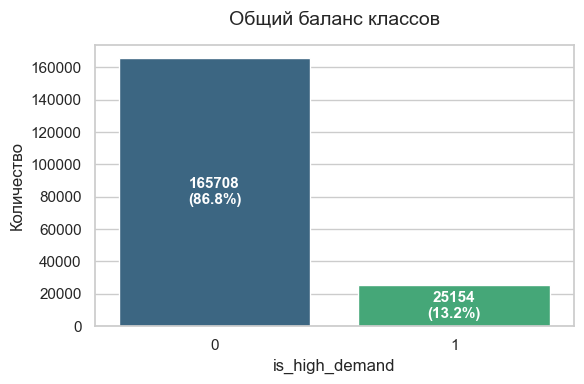

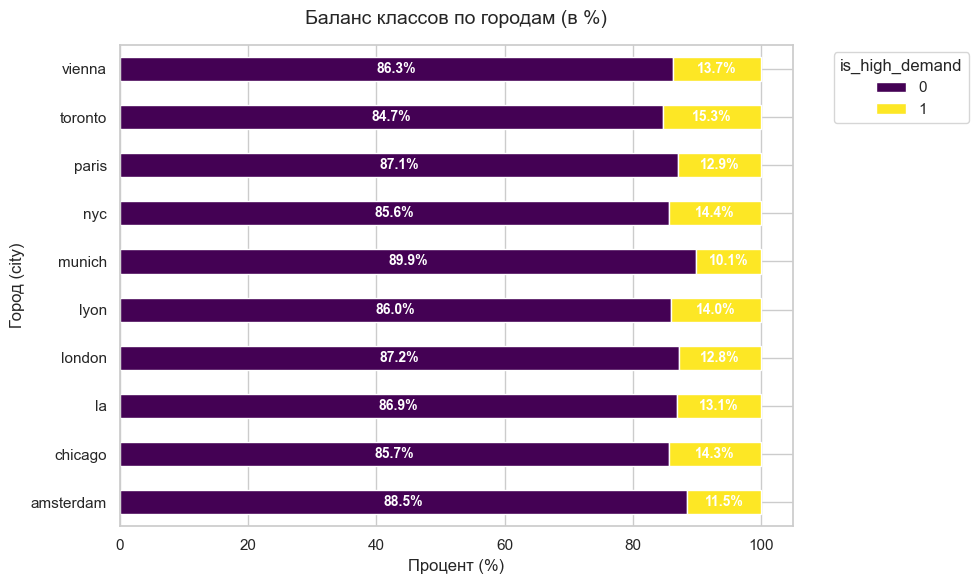

In [19]:
# Устанавливаем стиль графиков
sns.set_theme(style="whitegrid")

# График общего баланса классов
plt.figure(figsize=(6, 4))
ax1 = sns.countplot(data=full_df, x="is_high_demand", hue="is_high_demand", palette="viridis", legend=False)

# Добавляем проценты и количество над столбцами
total = len(full_df)
for p in ax1.patches:
    height = p.get_height()
    if height > 0:  # Проверяем, что столбец не пустой
        percentage = f"{100 * height / total:.1f}%"
        text = f"{int(height)}\n({percentage})"
        ax1.annotate(text, (p.get_x() + p.get_width() / 2., height / 2),
                    ha="center", va="center", color="white", fontsize=11, weight="bold")


plt.title("Общий баланс классов", fontsize=14, pad=15)
plt.xlabel("is_high_demand", fontsize=12)
plt.ylabel("Количество", fontsize=12)
plt.tight_layout()
plt.show()

# График баланса классов в разрезе каждого города (в % соотношении)
# Считаем кросс-таблицу в процентах
city_balance_pct = pd.crosstab(full_df["city"], full_df["is_high_demand"], normalize="index") * 100

# Строим накопленную (stacked) горизонтальную диаграмму для удобства чтения названий городов
ax2 = city_balance_pct.plot(kind="barh", stacked=True, figsize=(10, 6), colormap="viridis")

# Добавляем подписи процентов внутрь столбцов
for p in ax2.patches:
    width = p.get_width()
    if width > 5: # Выводим текст только если столбец не слишком узкий
        ax2.annotate(f"{width:.1f}%", (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
                    ha="center", va="center", color="white", fontsize=10, weight="bold")

plt.title("Баланс классов по городам (в %)", fontsize=14, pad=15)
plt.xlabel("Процент (%)", fontsize=12)
plt.ylabel("Город (city)", fontsize=12)
plt.legend(title="is_high_demand", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

В датасете содержатся объявления, которые модель не должна видеть. Старые "спящие" объявления могут иметь хорошие характеристики самого жилья, но у них целевая переменная = 0, так как они не активны за последний год. Новые объявления, которые ещё не успели набрать достаточно исторических данных о спросе, тоже могут быть с хорошими техническими характеристика, но таргет у них = 0. Эти две категории объявлений сильно усложнят модели поиск перспективных параметров жилья. 

Отфильтровать старые объявления можно сравнив количество отзывов за последний год и за всё время. Если за последний год отзывов не было, но раньше они были, это "спящее" объявление его лучше удалить.  Этот же фильтр нужно добавить в пайплайн модели, перед тем как она будет предсказывать таргет, иначе старые спящие объявления получат 'is_high_demand' = 1, если у них хорошие характеристики. Для бизнеса важно обозначить проблему "проснувшихся" объявлений, которые были неактивны, но возобновили работу. С такой фильтрациеё у них не будет шансов подняться. 

С новыми сложнее. Не имея даты создания\обновления объявления, трудно определить его возраст и ограничиться одним годом. У свежих объявлений может совсем не быть истории, такие уже были удалены из датасета при очистке пропусков в отзывах и рейтинге. Можно только дополниельно убрать объявления у которых все отзывы за последний год равны отзывам за последний месяц. Из них нужно обязательно оставить те, у которых 'is_high_demand' = 1.

In [16]:
# Запоминаем размер до фильтрации
before_filter = len(full_df)

# Категория 1: Спящие (были отзывы раньше, но за последний год — ноль)
is_sleeping = (full_df['numeric_of_reviews'] > 0) & (full_df['numeric_of_reviews_ltm'] == 0)

# Категория 2: Свежие (все отзывы за год получены только за последние 30 дней)
is_too_fresh = (full_df['numeric_of_reviews_l30d'] == full_df['numeric_of_reviews_ltm']) & (
    full_df['is_high_demand'] == 0)

# Объединяем условия для удаления
to_drop = is_sleeping | is_too_fresh

# Оставляем всё, что НЕ попадает под эти две категории
train_df = full_df[~to_drop].copy()

# Сбрасываем индексы в последовательный порядок
train_df = train_df.reset_index(drop=True)

# Выводим честный отчет
after_filter = len(train_df)
print(f"Было строк: {before_filter}")
print(f"Осталось для обучения: {after_filter}")
print(f"Удалено («спящие» + «недосозревшие новички»): {before_filter - after_filter}")


Было строк: 190862
Осталось для обучения: 152096
Удалено («спящие» + «недосозревшие новички»): 38766


Проверяем баланс классов:

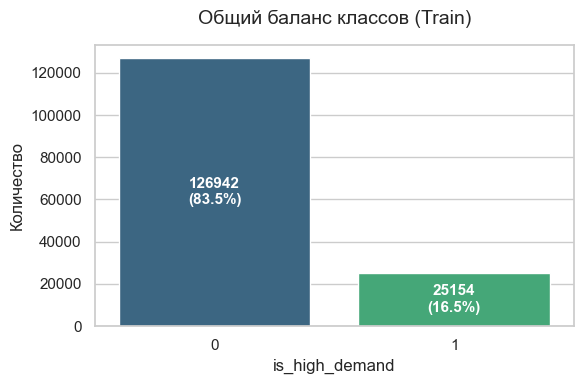

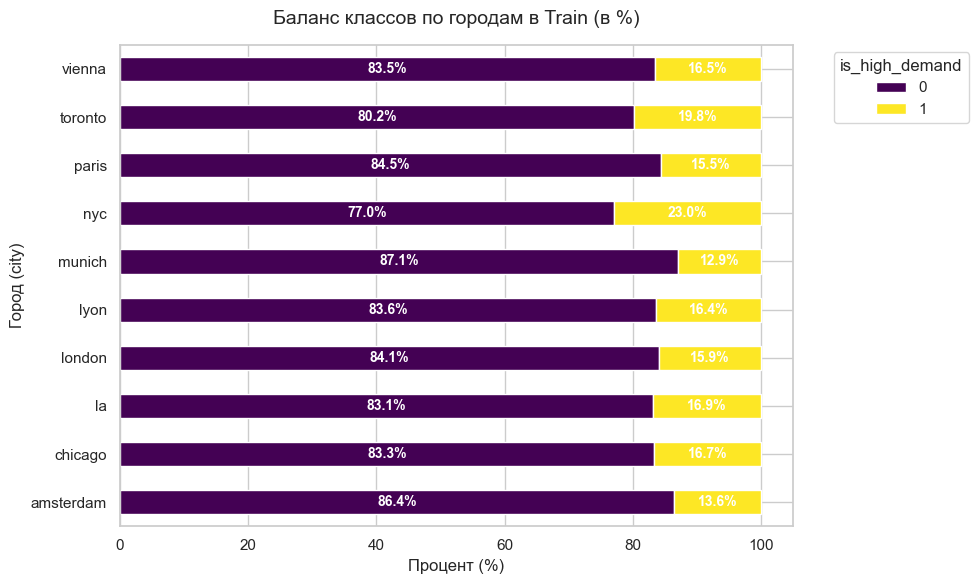

In [ ]:
# Устанавливаем стиль графиков
sns.set_theme(style="whitegrid")

# График общего баланса классов ---
plt.figure(figsize=(6, 4))
# Заменили full_df на train_df
ax1 = sns.countplot(data=train_df,
    x="is_high_demand",
    hue="is_high_demand",
    palette="viridis",
    legend=False)

# Добавляем проценты и количество внутрь столбцов
total = len(train_df)  # Заменили full_df на train_df
for p in ax1.patches:
    height = p.get_height()
    if height > 0:  # Проверяем, что столбец не пустой
        percentage = f"{100 * height / total:.1f}%"
        text = f"{int(height)}\n({percentage})"
        ax1.annotate(text,
            (p.get_x() + p.get_width() / 2., height / 2),
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            weight="bold")

plt.title("Общий баланс классов (Train)", fontsize=14, pad=15)
plt.xlabel("is_high_demand", fontsize=12)
plt.ylabel("Количество", fontsize=12)
plt.tight_layout()
plt.show()

# График баланса классов по городам ---
# Считаем кросс-таблицу в процентах для train_df
city_balance_pct = (
    pd.crosstab(train_df["city"], train_df["is_high_demand"], normalize="index")* 100)

# Строим накопленную (stacked) горизонтальную диаграмму
ax2 = city_balance_pct.plot(kind="barh", stacked=True, figsize=(10, 6), colormap="viridis")

# Добавляем подписи процентов внутрь столбцов
for p in ax2.patches:
    width = p.get_width()
    if width > 5:  # Выводим текст только если столбец не слишком узкий
        ax2.annotate(f"{width:.1f}%",
            (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            weight="bold")

plt.title("Баланс классов по городам в Train (в %)", fontsize=14, pad=15)
plt.xlabel("Процент (%)", fontsize=12)
plt.ylabel("Город (city)", fontsize=12)
plt.legend(title="is_high_demand", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Проверяем количество объявлений для каждого города:

In [19]:
city_counts = train_df.groupby("city").size().to_frame(name="Количество строк")
display(city_counts)


,Количество строк
city,
amsterdam,5644
chicago,6153
la,21223
london,47417
lyon,4749
munich,3902
nyc,9358
paris,35151
toronto,9765


**Баланс классов и выводы:**

Выборка сильно несбалансирована по объему данных: более 70% всех строк приходится всего на три крупнейших города — london (47,4 тыс.), paris (35,1 тыс.) и la (21,2 тыс.). При этом во всех представленных городах доминирует класс 0, доля которого стабильно колеблется в узком диапазоне от 77% до 87%. Наибольший относительный спрос (класс 1) зафиксирован в nyc (23.0%) и toronto (19.8%), в то время как в munich этот показатель минимален и составляет всего 12.9%.

## 4. Исключение утечек данных

Найдите и исключите все колонки, которые нельзя использовать как признаки. Обоснуйте каждое решение.

In [ ]:
columns_to_drop = ['id', 'source', 'host_id',
    'numeric_of_reviews', 'numeric_of_reviews_ltm', 'numeric_of_reviews_l30d',
    'first_review', 'last_review', 'review_scores_rating', 'is_high_demand']

**Исключённые колонки и обоснование:**

id — Уникальный идентификатор объявления. Для модели это просто случайный шум, который может привести к переобучению, если алгоритм попытается запомнить конкретные числа.

source — Источник выгрузки данных (например, внутренний скрапер или официальный API). Технический маркер сбора датасета, никак не связанный со спросом клиентов.

host_id — Уникальный идентификатор хозяина. Модель может переобучиться на крупных агентствах, у которых сотни квартир.

numeric_of_reviews — Общее количество отзывов. Это прямой показатель исторической популярности объекта.

numeric_of_reviews_ltm — Количество отзывов за последние 12 месяцев. Напрямую используется при расчете целевой переменной.

numeric_of_reviews_l30d — Количество отзывов за последние 30 дней. Прямой маркер текущего спроса.

first_review — Дата самого первого отзыва. Отражает возраст объявления на платформе, а не параметры жилья.

last_review — Дата последнего отзыва. Сильный маркер недавней активности.

review_scores_rating — Средняя оценка (рейтинг) жилья. Прямая утечка формулы таргета. Модель начнет опираться на оценку вместо анализа характеристик квартиры.

price -  Используется в таргете (через price_ratio). Прямая утечка — таргет от неё зависит.

'is_high_demand' - целевая переменная.

Эти признаки не должны попасть в датасет для модели. Пока их не удаляем, они могут понадобиться для анализа других признаков.

Признак host_listings_count — Общее количество объявлений у этого хоста, требует дополнительного исследования. Он может создать утечку данных, смещая фокус модели с качества конкретного жилья на масштаб бизнеса хозяина. Или стать хорошим хорошим маркером качественного жилья.

## 5. EDA

Исследуйте данные. Изучите распределения числовых и категориальных признаков, корреляции с таргетом, паттерны в данных. На основе EDA сформулируйте гипотезы для создания новых признаков с помощью feature engineering.

Чтобы тзбежать утечки данных при заполнении пропусков, создаём независимую копию датасета, которую в конце анализа данных разделим на выборки:

In [17]:
final_df = train_df.copy()

### 5.1 Числовые признаки

Создаём список числовых признаков:

In [21]:
numeric_features = ['latitude',
    'longitude',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'maximum_nights',
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm',
    'instant_bookable', 
    'host_listings_count',
    'host_has_profile_pic',
    'host_identity_verified',]

Проверяем пропуски:

In [22]:
missing = train_df[numeric_features].isnull().sum()
missing_pct = train_df[numeric_features].isnull().mean() * 100

missing_df = pd.DataFrame({
    'признак': numeric_features,
    'пропусков': missing.values,
    'доля_%': missing_pct.values.round(2)})
# Фильтруем: оставляем только признаки, где количество пропусков НЕ РАВНО нулю
missing_df = missing_df[missing_df['пропусков'] > 0]
missing_df

,признак,пропусков,доля_%
3,bathrooms,721,0.47
4,bedrooms,539,0.35
5,beds,801,0.53
6,minimum_nights,13,0.01
7,maximum_nights,13,0.01
8,minimum_minimum_...,67,0.04
9,maximum_minimum_...,67,0.04
10,minimum_maximum_...,67,0.04
11,maximum_maximum_...,67,0.04
14,instant_bookable,9358,6.15


Количество пропусков относительно не велико. Их можно заполнить не внося искажения в данные.

Проверяем какие значения есть в признаке подтверждения брони без участия хоста:

In [81]:
train_df['instant_bookable'].value_counts(dropna=False)

instant_bookable
False    93927
True     48811
None      9358
Name: count, dtype: int64

Если хост не указал, что мгновенное бронирование доступно — значит, скорее всего, недоступно. Это достаточно надёжная логика, чтобы заполнить пропуски. Возможность забронировать жильё без участия хоста является важной характеристикой объявления. Заполняем эти пропуски:

In [30]:
train_df['instant_bookable'] = train_df['instant_bookable'].fillna(False)

Потакому же принципу заполняем пропуски в 'host_has_profile_pic' и 'host_identity_verified'. Если значение пропущено, значит у хоста нет подтверждённой верификации и фото профиля.

In [31]:
train_df['host_has_profile_pic'] = train_df['host_has_profile_pic'].fillna(False)
train_df['host_identity_verified'] = train_df['host_identity_verified'].fillna(False)

Проверяем как представлены значения в признаке количества ванных:

In [23]:
train_df['bathrooms'].value_counts(dropna=False).head(10)

bathrooms
1.0    107856
2.0     19355
1.5     12364
2.5      4072
3.0      3251
3.5      1168
0.5       880
4.0       747
NaN       721
0.0       686
Name: count, dtype: int64

Проверяем значения в описаниях ванных:

In [86]:
train_df['bathrooms_text'].value_counts(dropna=False).head(10)

bathrooms_text
1 bath              83822
2 baths             17601
1 shared bath       12527
1 private bath      12056
1.5 baths           10083
2.5 baths            3755
3 baths              2966
1.5 shared baths     2308
2 shared baths       1772
3.5 baths            1138
Name: count, dtype: int64

Проверяем возможность востановить количество ванных из описания

In [87]:
two_bath_nan = train_df['bathrooms'].isnull() & train_df['bathrooms_text'].isnull()
print(f"Пропущены оба признака одновременно: {two_bath_nan.sum()}")

Пропущены оба признака одновременно: 55


In [24]:
# Где bathrooms пропущен, но bathrooms_text есть
can_fill = train_df['bathrooms'].isnull() & train_df['bathrooms_text'].notna()

total_missing = train_df['bathrooms'].isnull().sum()
can_fill_count = can_fill.sum()

print(f"Пропусков в bathrooms: {total_missing}")
print(f"Из них можно восстановить из bathrooms_text: {can_fill_count}")
print(f"Доля восстановимых: {can_fill_count / total_missing * 100:.1f}%")

Пропусков в bathrooms: 721
Из них можно восстановить из bathrooms_text: 666
Доля восстановимых: 92.4%


Извлекаем числа из описания ванных и заполняем пропуски:

In [25]:
# Функция извлечения числа из bathrooms_text с учётом half-bath
def extract_bathrooms(text):
    if pd.isna(text):
        return None
    text = text.lower()
    # half-bath, private half-bath, shared half-bath
    if 'half-bath' in text:
        return 0.5
    # извлекаем первое число
    match = re.search(r'([\d.]+)', text)
    if match:
        return float(match.group(1))
    return None

train_df['bathrooms_from_text'] = train_df['bathrooms_text'].apply(extract_bathrooms)

# Заполняем bathrooms
mask = train_df['bathrooms'].isnull() & train_df['bathrooms_from_text'].notna()
train_df.loc[mask, 'bathrooms'] = train_df.loc[mask, 'bathrooms_from_text']

# Удаляем временную колонку
train_df = train_df.drop(columns=['bathrooms_from_text'])

# Проверяем
print(f"Осталось пропусков в bathrooms: {train_df['bathrooms'].isnull().sum()}")

Осталось пропусков в bathrooms: 55


Осталось очень малое количество пропущенных значений. Их безболезненно можно заполнить нулями:

In [26]:
train_df['bathrooms'] = train_df['bathrooms'].fillna(0)
print(f"Осталось пропусков в bathrooms: {train_df['bathrooms'].isnull().sum()}")

Осталось пропусков в bathrooms: 0


Заполняем пропуски в количестве спален и спальных мест медианными значениями для подобной вместимости жилья:

In [27]:
# Заполняем bedrooms
train_df['bedrooms'] = train_df['bedrooms'].fillna(
    train_df.groupby('accommodates')['bedrooms'].transform('median'))

# Заполняем beds
train_df['beds'] = train_df['beds'].fillna(
    train_df.groupby('accommodates')['beds'].transform('median'))

print(f"Пропусков bedrooms: {train_df['bedrooms'].isnull().sum()}")
print(f"Пропусков beds: {train_df['beds'].isnull().sum()}")

Пропусков bedrooms: 0
Пропусков beds: 0


В максимальных и минимальных сроках аренды очень мало пропусков. Их можно заполнить медианами. А количество объявлений у хоста единицами, минимум одно у него есть:

In [28]:
for col in ['minimum_nights', 'maximum_nights', 
            'minimum_minimum_nights', 'maximum_minimum_nights',
            'minimum_maximum_nights', 'maximum_maximum_nights']:
    train_df[col] = train_df[col].fillna(train_df[col].median())

train_df['host_listings_count'] = train_df['host_listings_count'].fillna(1)

In [32]:
print("Проверка пропусков:")
print(train_df[numeric_features].isnull().sum()[numeric_features])

Проверка пропусков:
latitude                  0
longitude                 0
accommodates              0
bathrooms                 0
bedrooms                  0
beds                      0
minimum_nights            0
maximum_nights            0
minimum_minimum_nights    0
maximum_minimum_nights    0
minimum_maximum_nights    0
maximum_maximum_nights    0
minimum_nights_avg_ntm    0
maximum_nights_avg_ntm    0
instant_bookable          0
host_listings_count       0
host_has_profile_pic      0
host_identity_verified    0
dtype: int64


Исследуем статистику по признакам:

In [34]:
train_df[numeric_features].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
latitude,152096.0,46.482737,5.975118e+00,33.33854,43.64165,48.856709,51.49379,51.543455,51.591179,52.375910,5.242512e+01
longitude,152096.0,-27.631003,4.756974e+01,-118.90766,-73.99728,-0.108799,2.35083,4.891076,16.326412,16.389291,1.653468e+01
accommodates,152096.0,3.591561,2.242131e+00,1.00000,2.00000,3.000000,4.00000,6.000000,8.000000,12.000000,1.600000e+01
bathrooms,152096.0,1.308026,6.822885e-01,0.00000,1.00000,1.000000,1.50000,2.000000,2.500000,4.000000,4.200000e+01
bedrooms,152096.0,1.472432,1.009141e+00,0.00000,1.00000,1.000000,2.00000,3.000000,3.000000,5.000000,3.300000e+01
beds,152096.0,1.977383,1.409683e+00,0.00000,1.00000,2.000000,2.00000,4.000000,5.000000,7.000000,3.300000e+01
minimum_nights,152096.0,7.249402,1.627215e+01,0.00000,1.00000,2.000000,4.00000,30.000000,30.000000,32.000000,7.300000e+02
maximum_nights,152096.0,145044.013643,1.746428e+07,1.00000,60.00000,365.000000,365.00000,1125.000000,1125.000000,1125.000000,2.147484e+09
minimum_minimum_nights,152096.0,6.428223,1.263937e+01,0.00000,1.00000,2.000000,3.00000,30.000000,30.000000,32.000000,3.800000e+02
maximum_minimum_nights,152096.0,11.691281,3.397579e+01,1.00000,2.00000,3.000000,6.00000,30.000000,30.000000,127.000000,1.125000e+03


Географические характеристики выглядят нормально.
accommodates - медиана — 3 человек. 75% объявлений рассчитаны максимум на 4 человек. Максимум — 16. Распределение выглядит достаточно естественно. Признак очень полезный, вместимость напрямую характеризует предложение.

bathrooms - 75% — не более 1.5. Максимум 42 выглядит как явный выброс/ошибка данных. Его нужно исследовать.

bedrooms и beds - максимум — 50. 50 спален и кроватей для обычного объявления выглядит явно аномальным значением. Нужно проверить такие строки и понять, являются ли это ошибками или действительно крупными объектами.

minimum_nights - здесь распределение сильно скошено: медиана — 2, 75% — 5, 90% — 30 и максимум — 999. Среднее 9.93 значительно выше медианы из-за длинного хвоста. 999 выглядит как аномальное значение. Сам признак полезен: слишком большое минимальное количество ночей потенциально может снижать привлекательность объявления. Поэтому удалять признак не стоит, но выбросы необходимо обработать/проверить.

maximum_nights - медиана — 365, 90% — 1125, максимум — 2 147 483 647. Среднее — 126 937, что очевидно совершенно не отражает типичное объявление. Значение 2 147 483 647 особенно подозрительно — это максимальное значение знакового 32-битного целого числа и очень похоже на технический сбой/ошибочное значение.

minimum_minimum_nights - Распределение похоже на minimum_nights: медиана — 2, 90% — 30, максимум — 730. Признак потенциально полезен, но имеет длинный хвост.

maximum_minimum_nights - медиана — 3, 90% — 30, максимум — 1125. Сильного подозрительного значения уровня 2.1 млрд здесь нет. Распределение всё равно сильно скошено.

minimum_maximum_nights, maximum_nights_avg_ntm и maximum_maximum_nights - здесь снова серьёзная аномалия: медиана — 365, 75% — 1125, максимум — 2 147 483 647. Среднее огромно относительно медианы из-за экстремальных значений. Особенно подозрительно значение 2 147 483 647.Признак требует очистки/исследования.

minimum_nights_avg_ntm - медиана — 3, 90% — 30, максимум — 969. Распределение сильно скошено, но экстремумы не настолько очевидно технические, как в maximum_nights.

host_listings_count - медиана — 2, 95% — 111, максимум — 5 469. Среднее — 30.5, то есть почти в 15 раз больше медианы. Это говорит о сильной правосторонней асимметрии: большинство хостов управляют небольшим количеством объявлений, но есть крупные профессиональные хосты/операторы.

Отображаем распределения на боксплотах:

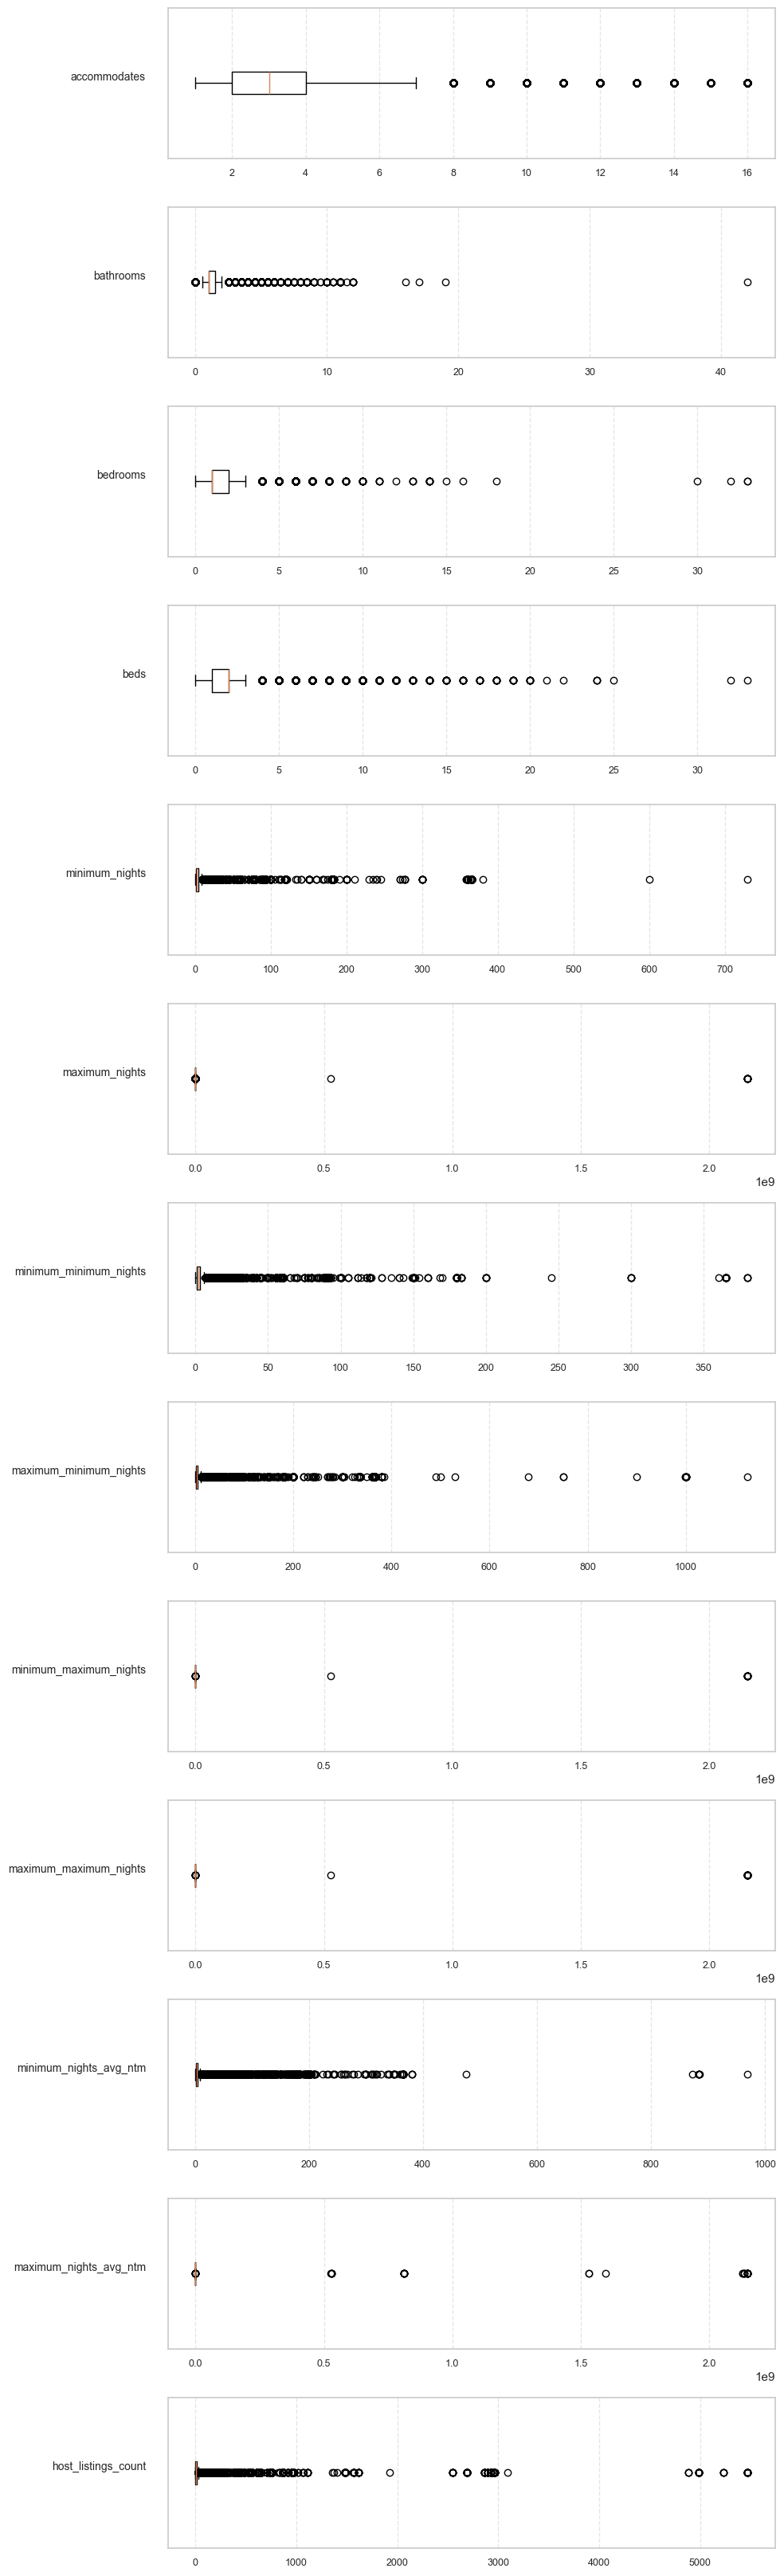

In [ ]:
features_to_plot = [col for col in numeric_features if col != 'instant_bookable']

# Динамически задаем количество строк по числу признаков
n_features = len(features_to_plot)

# Создаем сетку: n_features строк, 1 столбец. 
# Высоту (figsize) подстраиваем под количество признаков (2.5 дюйма на график)
fig, axes = plt.subplots(n_features, 1, figsize=(10, n_features * 2.5))

# Перестраховка на случай, если признак всего один (чтобы axes оставался массивом)
if n_features == 1:
    axes = [axes]

for i, col in enumerate(features_to_plot):
    # vert=False делает боксплот горизонтальным
    axes[i].boxplot(train_df[col].dropna(), vert=False)
    
    # Название признака пишем слева (вместо Y-tick), чтобы было нагляднее
    axes[i].set_ylabel(col, fontsize=10, rotation=0, labelpad=20, ha='right')
    # Убираем стандартные Y-типли, так как имя признака уже на оси Y
    axes[i].set_yticks([]) 
    
    axes[i].tick_params(axis='x', labelsize=9)
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)  # Добавляем сетку для удобства

plt.tight_layout()
plt.show()

Очень сильная правосторонняя асимметрия почти во всех признаках. Признаки accommodates, latitude, longitude, host_listings_count, minimum_minimum_nights, maximum_minimum_nights имеют распределение, которое действительно может отражать реальность и не требуют обработки.

Признаки bathrooms, bedrooms, beds, minimum_nights, minimum_nights_avg_ntm имеют некоторое число выбросов, которые могут быть естественными, но их следуе ограничить. Как и остальные признаки описывающие максимальное число ночей аренды. Там явно присутсвуют аномалии. 

Обрабатываем проблемные признаки. Если значение превышает 99-й процентиль, приравниваем значеие к нему, с округлением вверх: 

In [33]:
# Все числовые признаки, которые нужно обрезать
cols_to_clip = ['bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'maximum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm']

# Обрезаем значения выше 99-го перцентиля
for col in cols_to_clip:
    percentile_99 = train_df[col].quantile(0.99)
    # Округляем порог вверх
    upper_limit = np.ceil(percentile_99)
    # Заменяем значения выше порога на сам порог
    train_df[col] = train_df[col].clip(upper=upper_limit)

print("Обработка завершена.")

Обработка завершена.


Исследуем корреляцию признаков с целевой переменной:

In [36]:
phik_target = (
    train_df[numeric_features + ['is_high_demand']]
    .phik_matrix(interval_cols=numeric_features)
    ['is_high_demand']
    .drop('is_high_demand')
    .sort_values(ascending=False))
phik_target

bedrooms                  0.211253
minimum_nights            0.172804
accommodates              0.171288
beds                      0.160561
minimum_nights_avg_ntm    0.157131
bathrooms                 0.131731
maximum_nights            0.096129
maximum_nights_avg_ntm    0.089947
maximum_maximum_nights    0.088967
minimum_maximum_nights    0.088314
instant_bookable          0.087862
latitude                  0.070193
longitude                 0.041931
host_has_profile_pic      0.038806
maximum_minimum_nights    0.030477
host_listings_count       0.028979
minimum_minimum_nights    0.026443
host_identity_verified    0.024401
Name: is_high_demand, dtype: float64

Наиболее сильная зависимость с целевой переменной is_high_demand наблюдается у признака bedrooms (Phi_K = 0.211).
Умеренно слабая зависимость характерна для minimum_nights (0.173), accommodates (0.171), beds (0.161), minimum_nights_avg_ntm (0.157) и bathrooms (0.132).
Остальные признаки имеют слабую зависимость с целевой переменной, при этом значения Phi_K не превышают 0.10.
В целом все зависимости можно считать слабыми, поэтому ни один из рассмотренных признаков по отдельности не обеспечивает сильного разделения объектов по уровню спроса.

Признак host_listings_count не имеет корреляции с целевой переменной. Его можно оставить в датасете.

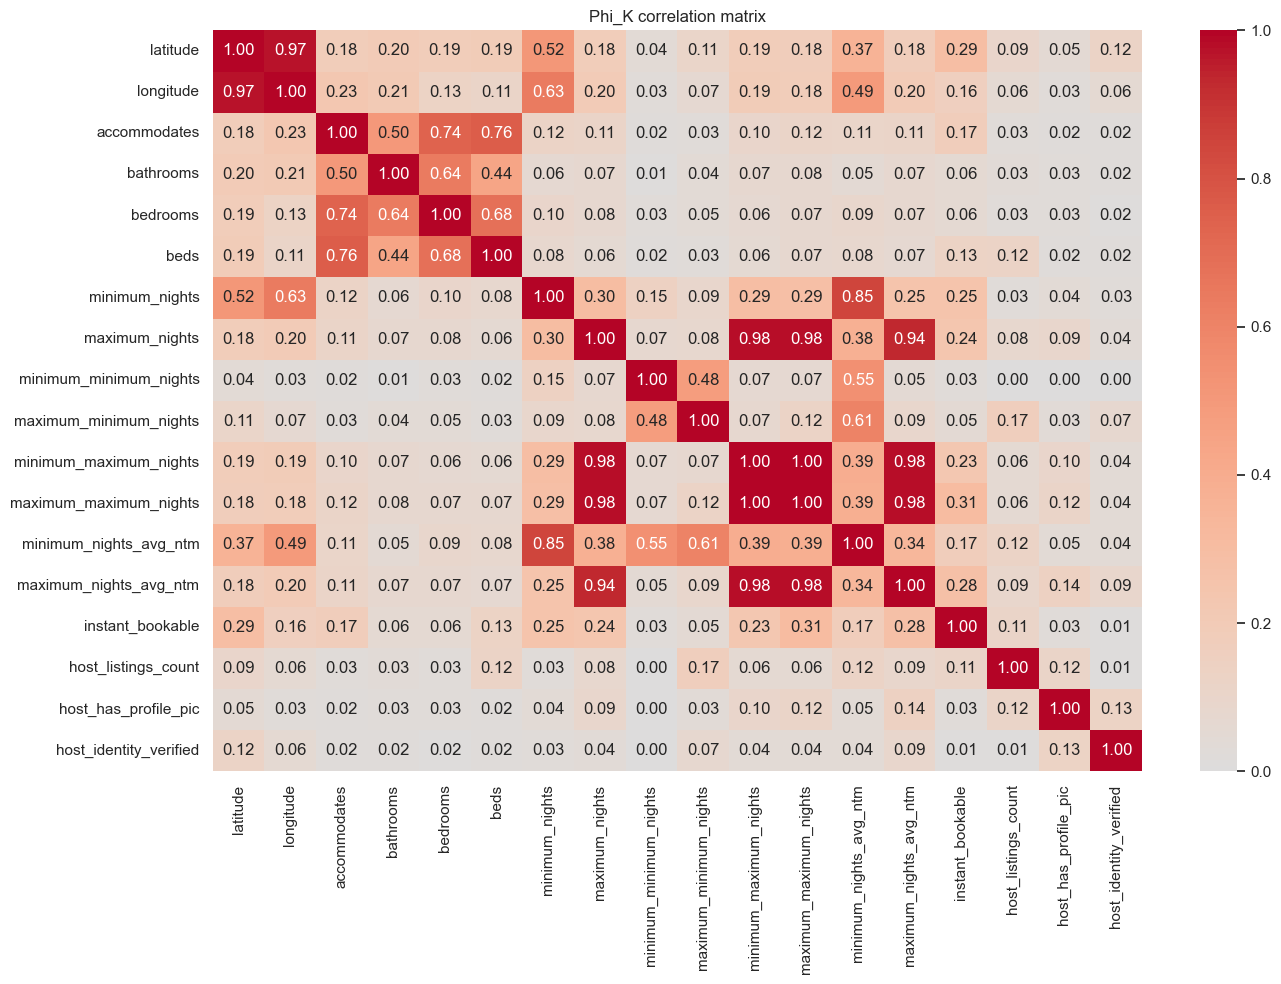

In [ ]:
phik_matrix = train_df[numeric_features].phik_matrix(interval_cols=numeric_features)

plt.figure(figsize=(14, 10))

sns.heatmap(phik_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0)

plt.title('Phi_K correlation matrix')
plt.tight_layout()
plt.show()

По матрице Phi_K видно несколько групп признаков с высокой взаимной зависимостью. Наиболее сильная зависимость наблюдается между latitude и longitude (0.97), а также внутри группы признаков, связанных с максимальным количеством ночей: minimum_maximum_nights и maximum_maximum_nights (1.00), maximum_nights и minimum_maximum_nights (0.98), maximum_nights и maximum_nights_avg_ntm (0.94). Также заметно связаны характеристики жилья: accommodates с beds (0.76) и bedrooms (0.74), bedrooms с bathrooms (0.64), а minimum_nights с minimum_nights_avg_ntm (0.85). В целом матрица указывает на наличие избыточных признаков, поэтому перед обучением модели стоит исключить несколько практически дублирующих признаков. Лучше удалить maximum_maximum_nights, minimum_maximum_nights и maximum_nights_avg_ntm.

In [34]:
features_to_drop = ['maximum_maximum_nights', 'minimum_maximum_nights', 'maximum_nights_avg_ntm']

numeric_features = [feature for feature in numeric_features if feature not in features_to_drop]

train_df = train_df.drop(columns=features_to_drop)

**Выводы:**

Числовые признаки содержали не большое количество пропущенных значений. Они были заполнены на основании данных из других признаков, медиан и логики отсутсвия данных.

Распределение значений в некоторых признааках было сильно скошено или имело аномалии. Это было скорректированно приведением слишком больших значений к 99-му процентилю.

Корреляция признаков с целевой переменной очень слабая. У всех Phi_K ниже 0.22.

Три признака с высокой коореляцией с другими были удалены.

### 5.2 Категориальные признаки

Создаём список категориальных признаков для удобсва работы:

In [35]:
categorical_features = ['city',
    'source',
    'neighbourhood_cleansed',
    'property_type',
    'room_type',
    'host_verifications', 
    'bathrooms_text']

Исследуем количество пропущенных значений:

In [36]:
for col in categorical_features:
    print(f'{col}: {train_df[col].isna().sum()} пропусков '
          f'({train_df[col].isna().mean() * 100:.2f}%)')

city: 0 пропусков (0.00%)
source: 0 пропусков (0.00%)
neighbourhood_cleansed: 0 пропусков (0.00%)
property_type: 0 пропусков (0.00%)
room_type: 0 пропусков (0.00%)
host_verifications: 9475 пропусков (6.23%)
bathrooms_text: 122 пропусков (0.08%)


Исследуем какие значения содержаться в признаках:

In [44]:
for col in categorical_features:
    print(f'\n{"=" * 6}')
    print(f'Признак: {col}')
    print(f'Количество уникальных значений: {train_df[col].nunique(dropna=False)}')
    print('\nТоп-10 значений:')
    print(train_df[col].value_counts(dropna=False).head(10))


Признак: city
Количество уникальных значений: 10

Топ-10 значений:
city
london       47417
paris        35151
la           21223
toronto       9765
nyc           9358
vienna        8734
chicago       6153
amsterdam     5644
lyon          4749
munich        3902
Name: count, dtype: int64

Признак: source
Количество уникальных значений: 2

Топ-10 значений:
source
city scrape        151423
previous scrape       673
Name: count, dtype: int64

Признак: neighbourhood_cleansed
Количество уникальных значений: 804

Топ-10 значений:
neighbourhood_cleansed
Westminster               6754
Camden                    3692
Kensington and Chelsea    3523
Tower Hamlets             3445
Buttes-Montmartre         3305
Popincourt                3016
Vaugirard                 2691
Hackney                   2516
Southwark                 2491
Entrepôt                  2447
Name: count, dtype: int64

Признак: property_type
Количество уникальных значений: 105

Топ-10 значений:
property_type
Entire rental unit 

Поскольку host_verifications содержит набор способов верификации, модель может получить больше информации, если создать отдельные бинарные признаки. Их будет всего три. Тип 'photographer' встречается всего один раз и его можно игнорироавть. Это же и решит проблему пропусков. Если ни чего не указано в объявлении, у всех трёх признаков будет стоять ноль. Сам по себе признак host_verifications лучше не использовать.

In [37]:
verification_cols = ['email', 'phone', 'work_email']

for verification in verification_cols:
    train_df[f'has_{verification}_verification'] = train_df['host_verifications'].apply(
        lambda x: int(
            verification in (ast.literal_eval(x) if isinstance(x, str) else (x if isinstance(x, list) else []))))
train_df.tail()

,city,id,source,name,description,neighborhood_overview,host_id,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_nights_avg_ntm,numeric_of_reviews,numeric_of_reviews_ltm,numeric_of_reviews_l30d,first_review,last_review,review_scores_rating,instant_bookable,is_high_demand,has_email_verification,has_phone_verification,has_work_email_verification
152091,vienna,1.481247e+18,city scrape,100м² | балкон |...,Welcome to this ...,NaN,659188559.0,10.0,"['email', 'phone']",True,True,Meidling,48.171529,16.32769,Entire rental unit,Entire home/apt,8.0,1.5,1.5 baths,2.0,4.0,"[""Smoke alarm"", ...",151.0,1.0,1125.0,1.0,30.0,10.1,1.0,1.0,0.0,2025-08-10,2025-08-10,1.00,True,0,1,1,0
152092,vienna,1.481652e+18,city scrape,Хорошо расположе...,This bright and ...,Situated in a we...,589598935.0,47.0,"['email', 'phone']",True,False,Rudolfsheim-Fnf...,48.194390,16.33002,Entire rental unit,Entire home/apt,6.0,1.0,1 bath,2.0,3.0,"[""Stove"", ""Coffe...",64.0,1.0,179.0,1.0,7.0,2.5,8.0,8.0,7.0,2025-08-11,2025-09-13,4.75,True,0,1,1,0
152093,vienna,1.481694e+18,city scrape,Простая 3-комнат...,This 80 m² 3-bed...,Daily essentials...,156404033.0,85.0,"['email', 'phone']",True,True,Ottakring,48.205160,16.33020,Entire rental unit,Entire home/apt,9.0,1.0,1 bath,3.0,5.0,"[""Stove"", ""Coffe...",125.0,1.0,179.0,1.0,7.0,2.6,8.0,8.0,5.0,2025-08-09,2025-08-31,4.38,True,0,1,1,0
152094,vienna,1.483635e+18,city scrape,"Стильно, рядом с...",🌆 Perfect locati...,This is where th...,547677118.0,142.0,"['email', 'phone']",True,True,Leopoldstadt,48.219120,16.38707,Room in hotel,Private room,2.0,1.0,1 private bath,1.0,1.0,"[""Smoke alarm"", ...",58.0,1.0,365.0,1.0,1.0,1.0,17.0,17.0,15.0,2025-08-14,2025-09-12,3.82,True,0,1,1,0
152095,vienna,1.483941e+18,city scrape,Прекрасное 5P пр...,This comfy 1BR a...,Schönbrunn Palac...,593098879.0,118.0,"['email', 'phone']",True,True,Hernals,48.214850,16.33958,Entire rental unit,Entire home/apt,5.0,1.0,1 bath,1.0,4.0,"[""Stove"", ""Coffe...",58.0,1.0,179.0,1.0,7.0,2.5,4.0,4.0,3.0,2025-08-14,2025-08-31,3.00,True,0,1,1,0


Таким же образом обрабатываем bathrooms_text. Число ванных из него уже извлекалось. Создаём один бинарный признак показывающий, что санузлы общего пользования. Пропущенны значения в количестве 0,08% заполнятся нулями, что может соответсвовать истине. Если не указано отдельно, что санузел общий, по умолчанию он отдельный. Исходный признак bathrooms_text использоваться не будет.

In [38]:
train_df['is_shared_bathroom'] = train_df['bathrooms_text'].str.contains(
    'shared', case=False, na=False
).astype(int)

Признак source для модели не даст ни какой информации. Он почти однородный, его лучше удалить. С признаки room_type и city для Logistic Regression лучше использовать ОНЕ, так как там не много уникальных значений. Для neighbourhood_cleansed и property_type подойдёт Target Encoding с обязательным применением сглаживания smooth='auto'.

**Выводы:**

Категориальные признаки имеют разную кардинальность: от 4 категорий у room_type до 804 у neighbourhood_cleansed, поэтому для них потребуется разный подход к кодированию. room_type, city и property_type целесообразно кодировать с помощью OHE, а для neighbourhood_cleansed из-за высокой кардинальности лучше использовать сглаженный Target Encoding. Четыре бинарных признака получились из преобразования  'host_verifications' и 'bathrooms_text'. Дальше они не понадобятся. Признак source оказался бесполезным для дальнейшего использоваия. Пропусков во всех признаках нет. При выборе признаков для Logistic Regression дополнительно следует учитывать их связь с целевой переменной и взаимную корреляцию, чтобы исключить малоинформативные и избыточные признаки.

### 5.3 Корреляционный анализ

Создаём список признаков для исследования корреляций:

In [ ]:
categorical_for_phik = ['city',
    'neighbourhood_cleansed',
    'property_type',
    'room_type',
    'has_email_verification',
    'has_phone_verification',
    'has_work_email_verification', 
    'is_shared_bathroom']

Проверяем корреляцию признаков с целевой переменной:

interval columns not set, guessing: ['has_email_verification', 'has_phone_verification', 'has_work_email_verification', 'is_shared_bathroom', 'is_high_demand']


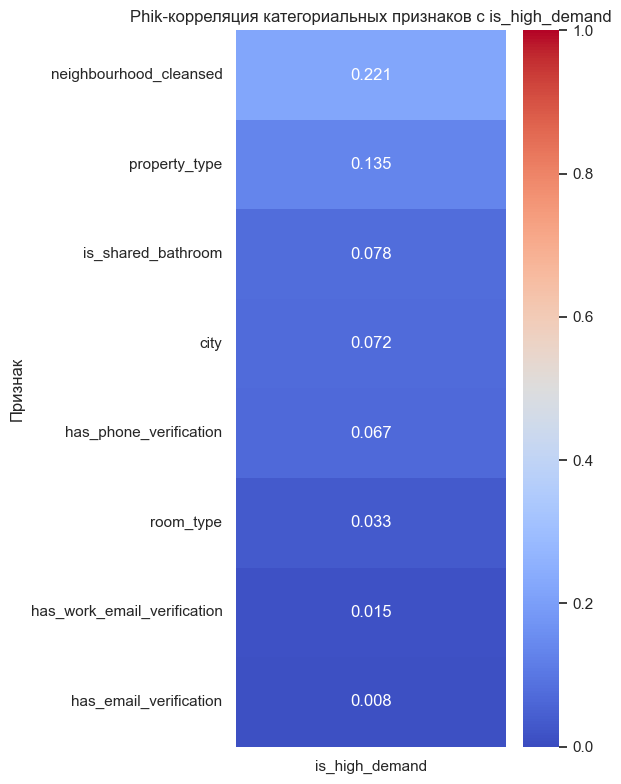

In [ ]:
phik_target = train_df[categorical_for_phik + ['is_high_demand']].phik_matrix()

# Сортируем по убыванию корреляции и берём только столбец с target, удаляя строку самого таргета
phik_target_corr = (phik_target[['is_high_demand']]
    .sort_values(by='is_high_demand', ascending=False)
    .drop('is_high_demand'))

# Тепловая карта
plt.figure(figsize=(6, 8))
sns.heatmap(phik_target_corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=0,
    vmax=1)

plt.title('Phik-корреляция категориальных признаков с is_high_demand')
plt.xlabel('')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

Конкретный район neighbourhood_cleansed (0.221) и тип недвижимости property_type (0.135) обладают наибольшей силой связи с целевой переменной. Влияние признаков общего пользования ванной is_shared_bathroom (0.078) и города city (0.072) оказалось слабым, подтверждая важность именно локальных характеристик внутри мегаполиса. Тип комнаты room_type (0.033) и все признаки верификации аккаунта (менее 0.067) демонстрируют околонулевую корреляцию, практически не влияя на популярность объявлений.

interval columns not set, guessing: ['has_email_verification', 'has_phone_verification', 'has_work_email_verification', 'is_shared_bathroom']


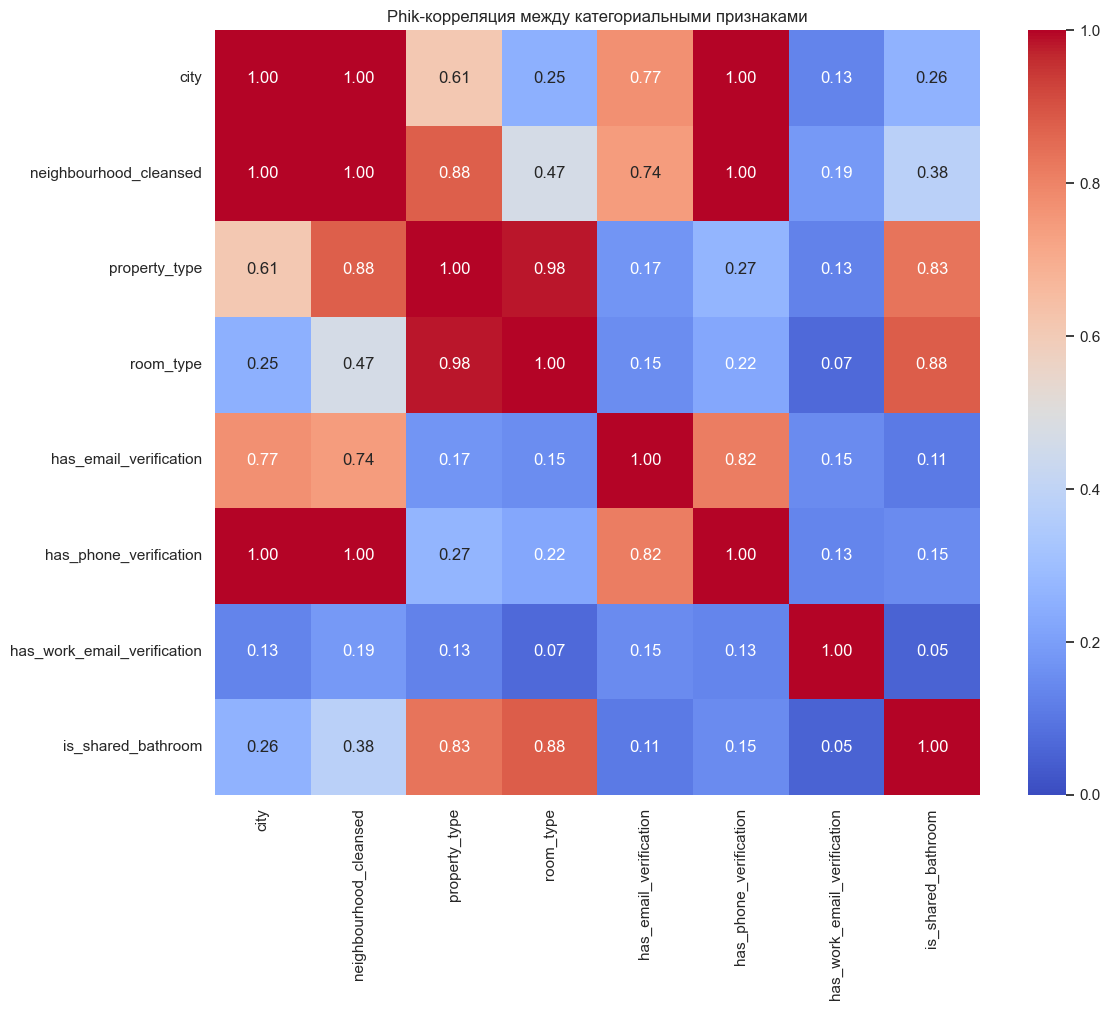

In [65]:
# Матрица Phik только для признаков
phik_features = train_df[categorical_for_phik].phik_matrix()

# Тепловая карта
plt.figure(figsize=(12, 10))

sns.heatmap(phik_features,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    square=True)

plt.title('Phik-корреляция между категориальными признаками')
plt.tight_layout()
plt.show()

Анализ матрицы выявил критически сильную взаимосвязь между географическими признаками и подтверждениями профиля, где город, конкретный район и наличие телефона дублируют информацию друг друга. Высокая зависимость также наблюдается между типами недвижимости, форматами комнат и характеристиками ванных комнат, поскольку тип арендуемого объекта жестко предопределяет устройство жилого пространства. Подобная избыточность указывает на выраженную мультиколлинеарность в данных, из-за чего сохранение всех признаков одновременно перегрузит модели и исказит их веса. Признак city лучше удалить, так как он дублирует информацию из долготы и широты, а названия района расположения дадут больше возможности для предсказаний. Для линейной модели лучше не показывать признаки room_type и has_phone_verification так как они сильно коррелируют с более информативными признаками.

**Выводы:**

Анализ матрицы выявил критически сильную взаимосвязь между географическими признаками и подтверждениями профиля, где город, конкретный район и наличие телефона дублируют информацию друг друга. Высокая зависимость также наблюдается между типами недвижимости, форматами комнат и характеристиками ванных комнат, поскольку тип арендуемого объекта жестко предопределяет устройство жилого пространства. Подобная избыточность указывает на выраженную мультиколлинеарность в данных, из-за чего сохранение всех признаков одновременно перегрузит линейные модели и исказит их веса. Для линейной модели лучше не показывать признаки room_type и has_phone_verification так как они сильно коррелируют с более информативными признаками. Для модели CatBoost это не создаст проблем. Возможно, она же сможет выявить связь всех признаков с целевой переменной, что линейной модели вряд ли удастся сделать.

### 5.4 Текстовые данные

Изучите названия листингов `name` и отзывы `reviews`. Сформулируйте гипотезы о том, какие текстовые признаки стоит создать.

Использование отзывов создаст утечку данных, так как будет показывать модели результаты уже реализованного спроса. Тогда модель не сможет правильно оценивать новые объявления у которых ещё нет истории. В качестве текстовых признаков стоит рассмотреть названия объявлений - 'name', описание жилья от хоста - 'description', список удобств - 'amenities' и описание района от хозяина - 'neighborhood_overview'.

Исследуем пропуски в этих признаках:

In [ ]:
text_features = ['name',
    'description',
    'amenities',
    'neighborhood_overview']

for col in text_features:
    print(f'{col}:')
    print(f'  Всего: {len(train_df)}')
    print(f'  Заполнено: {train_df[col].notna().sum()}')
    print(f'  Пропусков: {train_df[col].isna().sum()}')
    print(f'  Доля пропусков: {train_df[col].isna().mean() * 100:.2f}%')
    print()

name:
  Всего: 152096
  Заполнено: 152096
  Пропусков: 0
  Доля пропусков: 0.00%

description:
  Всего: 152096
  Заполнено: 149945
  Пропусков: 2151
  Доля пропусков: 1.41%

amenities:
  Всего: 152096
  Заполнено: 152096
  Пропусков: 0
  Доля пропусков: 0.00%

neighborhood_overview:
  Всего: 152096
  Заполнено: 69589
  Пропусков: 82507
  Доля пропусков: 54.25%



В столбце neighborhood_overview пропущенно более половины значений, востановить их не представляется возможным, поэтому от него лучше отказаться.

Проверим какой характер имеет текст в признаках:

In [ ]:
pd.set_option('display.max_colwidth', None)
train_df[['name', 'description', 'amenities']].head()

,name,description,amenities
0,"Романтический, стильный плавучий дом типа «постель и завтрак» в районе каналов","Stylish and romantic houseboat on fantastic historic location with breathtaking view. Wheelhouse, deckhouse and captains room. Central, quiet. Great breakfast, 2 vanMoof design bikes and a Canadian Canoe are included. Just read the reviews on tripadvisor for instance!","[""Canal view"", ""Coffee"", ""Private backyard \u2013 Not fully fenced"", ""Bikes"", ""Portable fans"", ""Books and reading material"", ""Fast wifi \u2013 245 Mbps"", ""Hangers"", ""Paid street parking off premises"", ""Shower gel"", ""Breakfast"", ""Wine glasses"", ""Dining table"", ""Private living room"", ""Hot water"", ""Bed linens"", ""TV with standard cable"", ""Heating - split type ductless system"", ""Long term stays allowed"", ""Central heating"", ""Self check-in"", ""Private patio or balcony"", ""City skyline view"", ""Shampoo"", ""Kayak"", ""Fire extinguisher"", ""Luggage dropoff allowed"", ""Outdoor dining area"", ""Hp neutral, eco friendly body soap"", ""Garden view"", ""Laundromat nearby"", ""Air conditioning"", ""Lake access"", ""Smart lock"", ""Dedicated workspace"", ""Boat slip"", ""Mini fridge"", ""Harbor view"", ""Hair dryer"", ""Private entrance"", ""Carbon monoxide alarm"", ""Coffee maker: Nespresso"", ""Safe"", ""Extra pillows and blankets"", ""Smoke alarm"", ""Refrigerator"", ""Essentials"", ""Outdoor furniture"", ""Waterfront"", ""Clothing storage: closet""]"
1,Комфортабельный двухместный номер,Basic bedroom in the center of Amsterdam.,"[""Heating"", ""Lock on bedroom door"", ""Hair dryer"", ""Private entrance"", ""Carbon monoxide alarm"", ""Cleaning products"", ""Smoke alarm"", ""Refrigerator"", ""Wifi"", ""Hot water"", ""Bed linens"", ""Hangers"", ""Essentials"", ""Host greets you"", ""Iron"", ""Shampoo"", ""Coffee maker"", ""Fire extinguisher""]"
2,Комфортабельный одноместный/двухместный номер,This room can also be rented as a single or a small double<br /><br />Also a cat lives here,"[""Heating"", ""Lock on bedroom door"", ""Hair dryer"", ""Private entrance"", ""Carbon monoxide alarm"", ""Smoke alarm"", ""Refrigerator"", ""Wifi"", ""Hot water"", ""Bed linens"", ""Hangers"", ""Essentials"", ""Host greets you"", ""Iron"", ""Shampoo"", ""Coffee maker"", ""Shower gel"", ""Fire extinguisher""]"
3,Очаровательная квартира в старом центре,"A beautiful, quiet apartment in the center of Amsterdam with view over the canal.","[""Shampoo"", ""Paid street parking off premises"", ""Single level home"", ""Essentials"", ""Dishwasher"", ""Waterfront"", ""Private entrance"", ""TV with standard cable"", ""Pack \u2019n play/Travel crib"", ""Washer"", ""Long term stays allowed"", ""Coffee maker"", ""Piano"", ""Cooking basics"", ""Cleaning products"", ""Smoke alarm"", ""Freezer"", ""Refrigerator"", ""Wifi"", ""Stove"", ""Sound system"", ""Wine glasses"", ""Canal view"", ""Cleaning available during stay"", ""Conditioner"", ""First aid kit"", ""Hot water"", ""Clothing storage: closet"", ""Books and reading material"", ""Bed linens"", ""Hangers"", ""Kitchen"", ""Carbon monoxide alarm"", ""Heating"", ""Dishes and silverware"", ""Hair dryer"", ""Body soap"", ""Oven"", ""Fire extinguisher"", ""Coffee"", ""Host greets you"", ""Dining table"", ""Hot water kettle""]"
4,Роскошный гостевой люкс Multatuli в отличном месте,"Stylish & spacious 60m2 guest suite in Amsterdam's most desirable neighbourhood. Central and convenient. Perfectly placed in easy walking distance of all the sights, transport, shops, cafes and restaurants. Quiet and peaceful bedroom, large and light living room (can be used as second bedroom), luxurious and spacious bathroom, handy pantry. The house is a national monument built in 1790, completely renovated in 2019. In the 1820s it was the home of Multatuli, Holland's most famous author.","[""Coffee"", ""Bikes"", ""Portable fans"", ""Toaster"", ""Wifi"", ""TV with Chromecast"", ""Books and reading material"", ""Hangers"", ""Babysitter re

Признак description дублирует описание объявления из других колонок. Он будет мало информативен и отнимет ресурсы на обработку текста. Его лучше удалить.

Исследуем на каких языках могут быть тексты признака name:

In [35]:
# Задаем фиксированный random state для воспроизводимости результатов langdetect
DetectorFactory.seed = 42

# Функция для определения языка с учётом пропусков
def detect_language_safe(text):
    # Проверяем, что это строка и она не пустая
    if not isinstance(text, str) or pd.isna(text) or text.strip() == "":
        return "unknown"
    try:
        # Берем первые 200 символов
        return detect(text[:200])
    except Exception:
        # Если langdetect не смог распознать язык
        return "unknown"

# Применяем функцию к признаку description
# (это самый длинный и надежный текст для анализа языка)
train_df["name_lang"] = train_df["name"].apply(detect_language_safe)

# Выводим топ языков в штуках и процентах
lang_counts = train_df["name_lang"].value_counts()
lang_pct = train_df["name_lang"].value_counts(normalize=True) * 100

# Объединяем результаты в таблицу
lang_report = pd.DataFrame({"Количество (шт)": lang_counts, "Доля (%)": lang_pct})

# Выводим результат
lang_report.head(10)

,Количество (шт),Доля (%)
name_lang,,
ru,130587,85.858274
bg,11383,7.484089
en,3416,2.245950
uk,1862,1.224227
mk,1155,0.759389
et,1042,0.685094
fr,843,0.554255
de,354,0.232748
af,337,0.221571


Текстовый признак name для линейной модели лучше обработать в пайплайне с помощью инструмента векторизации TfidfVectorizer. Можно использовать параметр stopwords.words('russian') только для русского языка, остальные языки представлены очень слабо и не повлияют на результат, но очень перегрузят модель, если их обрабатывать. 

Модель CatBoost обладает встроеными методами обработки текста и для неё их нужно будет только указать.

Признак amenities содержит много полезной информации о доступных удобствах. Его так же можно подвергнуть векторизации. Но сначала нужно преобразовать названия удобств, заменив пробелы на "_".


Нет смысла делать отдельные признак для всех уникальных удобств. Исследуем какие удобства встречаются и в каком количестве:

In [72]:
# Преобразуем строковое представление списка в настоящий список
amenities_lists = train_df['amenities'].apply(ast.literal_eval)

# Считаем частоту каждого удобства
amenities_counter = Counter(amenity
    for amenities in amenities_lists
    for amenity in amenities)

# Количество уникальных удобств
print(f'Количество уникальных amenities: {len(amenities_counter)}')

# Топ-50 наиболее распространённых удобств
print('\nТоп-50 удобств:')
print(pd.DataFrame(amenities_counter.most_common(50),
        columns=['amenity', 'count']
    ).to_string(index=False))

# Количество удобств, встречающихся реже заданного количества раз
print('\nРедкие удобства:')
print(f'Менее 10 раз:  {(sum(1 for x in amenities_counter.values() if x < 10))}')
print(f'Менее 50 раз:  {(sum(1 for x in amenities_counter.values() if x < 50))}')
print(f'Менее 100 раз: {(sum(1 for x in amenities_counter.values() if x < 100))}')

Количество уникальных amenities: 24172

Топ-50 удобств:
                              amenity  count
                                 Wifi 138007
                              Kitchen 137177
                          Smoke alarm 136323
                            Hot water 134870
                           Hair dryer 123874
                Dishes and silverware 123194
                           Bed linens 121862
                              Hangers 119611
                                 Iron 115817
                           Essentials 115088
                       Cooking basics 114491
                         Refrigerator 112609
                            Microwave 105688
                Carbon monoxide alarm  98704
                     Hot water kettle  97042
                              Shampoo  94151
                  Dedicated workspace  89603
                         Dining table  85078
                                   TV  84913
                              Heating  84869

Топ-100 распространённых удоств это 98% от всех встречающихся. При векторизации можно использовать параметр min_df=100, тогда он будет игнорировать ВСЁ, что встречается реже 100 раз во всем датасете.

**Выводы:**

Использовать отзывы в качестве признаков нельзя, это покажет модели какие объявления уже были успешными. Текстовый признак name можно подать в CatBoost напрямую, а для линейной модели применить TfidfVectorizer. Признак amenities лучше векторизировать перед подачей для обоих моделей.

### 5.5 Итоги EDA

Зафиксируйте ключевые наблюдения и план по созданию новых признаков.

**Ключевые наблюдения:**

1. Числовые признаки имеют сильно скошеное распределение. Содержали мало пропусков, которые были заполнены апроксимацией, медианой или логически. Сильные выбросы и аномалии заменены на 99-й процентиль. Удалены три признаки описывающие максимвльный срок аренды из-за высокой корреляции с другими.
2. Для логистической регрессии критически важно применить StandardScaler из-за сильного скоса распределений и разного масштаба чисел
3. В категориальных признаках пропуски в host_verifications и bathrooms_text не заполнялись. Признаки преобразованы в дополнительные бинарные по типам верификации хоста и наличия ванных общего пользования. Остальные признаки из-за высокой кардинальности лучше кодировать с помощью Target Encoding для логистической регрессии. Во избежание утечки данных, Target Encoding будет рассчитываться строго внутри пайплайна. Пропущенных значений в признаках нет. 
4. Анализ корреляции показал очень слабую связь и числовых и категориальных признаков с целевой переменной. Максимум 0.221 у neighbourhood_cleansed - стандартизованного названия района. Для линейной модели лучше не показывать признаки city, room_type и has_phone_verification так как они сильно коррелируют с более информативными признаками.
5. Из текстовых признаков можно использовать name и amenities. Они представлены, в основном, на русском и английском языках. Обрабатыват другие языки не имеет смысл, из-за их крйне малого количества. Признак name можно подавать в CatBoost напрямую (с указанием, что он текстовый), а для Логистической регрессии применить векторизацию. Описание количества удобств - amenities, лучше предварительно векторизировать для всех моделей. 
6. Из-за объема выборки (~150 тыс. строк) и разной скорости моделей будет применен комбинированный подход: кросс-валидация для быстрой логистической регрессии и выделенная валидационная выборка с механизмом ранней остановки для CatBoost, что сэкономит вычислительные ресурсы без потери качества оценки.

---

**Новые признаки**, которые планируете создать (если это необходимо) в соответствии со своим обоснованием на основе EDA.

| Признак | Источник | Гипотеза |
|---------|----------|----------|
| amenities_count — общее количество удобств у объявления| amenities | Для отражения общего количества удобств, доступных в объявлении. Чем больше набор удобств, тем потенциально выше привлекательность объекта для пользователей. |
|host_trust_score | host_verifications + host_identity_verified + host_has_profile_pic|Индекс доверия к профилю. Насколько открыт и заполнен профиль хозяина, что напрямую влияет на психологическое доверие гостя перед бронированием. |
|guests_per_bedroom |Отношение accommodates к bedrooms |Плотность размещения гостей. Насколько «тесно» будет гостям в этом жилье. Показывает реальную эргономику пространства. Слишком высокая плотность (например, 6 гостей на 1 спальню) указывает на хостельный тип или надуманную вместимость. Жилье с оптимальной плотностью (2 гостя на 1 спальню) предлагает больший комфорт, легче удерживает высокий рейтинг и цену выше медианы.|
|is_shared_bathroom |Бинарный признак слова "shared" в признаке 'bathrooms_text'|Наличие санузла общего пользования может быть важным для апривлекательности аренды жилья|


## 6. Обработка пропусков (если необходимо)

Обработайте пропуски согласно стратегии, выработанной в результате EDA. Все решения обоснуйте.

Большинство пропусков были обработаны на этапе EDA. 

**Стратегия обработки пропусков:**

Выбор медианы, а не среднего связан с тем, что медиана позволяет сохранить естественный центр распределения, устойчива к аномалиям и предоставляет модели стабильную "заглушку", репрезентативную для большинства типичных объявлений.

| Колонка | % пропусков | Стратегия | Обоснование |
|---------|------------|-----------|-------------|
|bathrooms| 0.47 | извлечение значений из bathrooms_text| В столбце bathrooms_text есть числовая и текстовая информация о количестве ванных. Остальные 55 пропуска заполнены нулями, исходя из того, что при отсутсвии описания ванных нет.  |
|bedrooms\beds | 0.35\0.53|медианными значениями для подобной вместимости жилья accommodates | Доля пропусков крайне мала и такое заполнение не искажает данные|
| minimum_nights\maximum_nights|0.01| медиана| Медиана даёт какое-то представление о сроках аренды. Из других источников получит эти данные невозможно. Низкая доля пропусков позволяет так поступить.|
| minimum_minimum_nights, maximum_minimum_nights, minimum_maximum_nights, maximum_maximum_nights| 0.04| медиана| крайне низкая доля пропусков, при которой удаление строк нецелесообразно, а усложненные методы импутации не дадут прироста в качестве|
|instant_bookable|6.15 | значение "False"|Если хост не указал такой важный признак, как возможность забронировать жильё без его подтверждения, значит этого сделать нельзя. |
|host_has_profile_pic, host_identity_verified |0.24| значение "False"| Если не указано наличие, скорее всего, верификация и фото отсутствуют|
|host_listings_count |0.24 |1 | Как минимум одно объявление у хоста точно есть|
|host_verifications|6.23 |0 | Сам признак в моделях использоваться не будет. Он преобразован в три новых бинарных признака, показывающих наличие способа верификации. Там где значения были пропущены, во всех трёх признаках будут нули, если хост не указал способ верификации, значит иё не было.|
|bathrooms_text| 0.08 | 0| Из этого признака извлечена вся полезная информация. Востановленно число ванных комнат и создан бинарный признак санузлов общего пользования. Если в тексте это не указано специально, скорее всего, санузел отдельный.|

## 7. Feature Engineering (если необходимо)

Создайте новые признаки, обоснованные EDA.

Создаём признак с количеством удобств:

In [45]:
# Быстрый подсчет по количеству запятых (если строка пустая "[]", вернет 0)
train_df['amenities_count'] = train_df['amenities'].apply(lambda x: x.count(',') + 1 if x != '[]' else 0)

Создаём индекс доверия к профилю. Насколько открыт и заполнен профиль хозяина жилья:

In [39]:
train_df['host_trust_score'] = (train_df['has_email_verification'] + 
    train_df['has_phone_verification'] + 
    train_df['has_work_email_verification'] + 
    train_df['host_identity_verified'].map({'False': 0, 'True': 1}).fillna(0).astype(int) + 
    train_df['host_has_profile_pic'].map({'False': 0, 'True': 1}).fillna(0).astype(int))

Создаём признак плотности заселения жилья. Плотность размещения гостей. Насколько «тесно» будет гостям в этом жилье.

In [40]:
train_df['guests_per_bedroom'] = np.where(train_df['bedrooms'] > 0, 
    train_df['accommodates'] / train_df['bedrooms'], 0)

In [46]:
# Список новых признаков
new_features = ['amenities_count',
    'host_trust_score',
    'guests_per_bedroom']

Проверяем результат:

In [47]:
train_df[new_features].head()

,amenities_count,host_trust_score,guests_per_bedroom
0,51,2,2.0
1,18,2,2.0
2,18,2,2.0
3,43,2,1.5
4,52,3,1.5


interval columns not set, guessing: ['amenities_count', 'host_trust_score', 'guests_per_bedroom', 'is_high_demand']


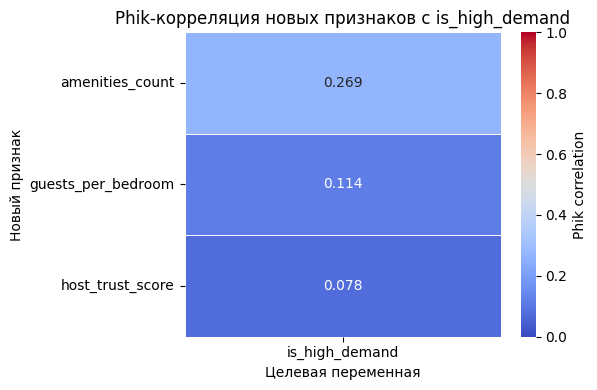

In [48]:
# Расчет phik-корреляции только для новых признаков
phik_target_new = train_df[new_features + ['is_high_demand']].phik_matrix(njobs=1)

# Сортируем по убыванию корреляции и берём только столбец с target, удаляя строку самого таргета
phik_target_corr_new = (phik_target_new[['is_high_demand']]
    .sort_values(by='is_high_demand', ascending=False)
    .drop('is_high_demand'))

# Тепловая карта
plt.figure(figsize=(6, 4))
sns.heatmap(phik_target_corr_new, annot=True, fmt='.3f', cmap='coolwarm', vmin=0, vmax=1, linewidths=0.5,
    cbar_kws={'label': 'Phik correlation'})

plt.title('Phik-корреляция новых признаков с is_high_demand')
plt.xlabel('Целевая переменная')
plt.ylabel('Новый признак')
plt.tight_layout()
plt.show()

Наибольшую взаимосвязь с целевой переменной is_high_demand демонстрирует признак amenities_count (Phik-корреляция 0.269), что указывает на заметное влияние разнообразия удобств на высокий спрос. Показатель guests_per_bedroom имеет более слабую, но всё же заметную корреляцию на уровне 0.114. Рейтинг доверия к хозяину (host_trust_score) практически не связан с целевым признаком, показывая минимальный коэффициент 0.078. Но, возможно, модель CatBoost сможет уловить зависимости.

**Созданные признаки и обоснование:**

amenities_count -  Количество удобств напрямую влияет на привлекательность жилья для гостей и показывает наивысшую Phik-корреляцию (0.269) среди новых признаков. Его добавление поможет модели уловить закономерность, что более оснащенные объекты чаще попадают в категорию высокого спроса.

guests_per_bedroom - Этот признак отражает плотность заселения и тип жилья, разделяя просторные апартаменты и переполненные хостелы. Он помогает модели оценить экономическую выгоду или комфорт объекта для арендаторов.

host_trust_score -  агрегирует уровень верификации и надежности хозяина, что важно для безопасности и доверия путешественников. Даже при невысокой линейной корреляции (0.078) этот комплексный признак может усилить нелинейные модели в связке с другими метриками сервиса.

## 8. Кодирование и масштабирование (если необходимо)

Закодируйте категориальные признаки. Примените масштабирование там, где оно нужно. Объясните, для каких моделей необходимы такие преобразования и почему.

Алгоритмы градиентного бустинга на деревьях решений (включая CatBoost) устойчивы к масштабу данных, так как они строят разделения (сплиты) в узлах деревьев на основе пороговых значений (например, amenities_count > 5). Для модели логистической регрессии кодироваие и масштабирование лучше встроить в её пайплайн. 


**Решения по кодированию и масштабированию:**

Кодирование и масштабирование будет проводится на этапе экспериментов с моделями. Чтобы избежать утечки данных.

## 9. Деление на выборки

Разделите данные на обучающую и тестовую выборки. Обоснуйте пропорции и стратегию разделения.

Определяем признаки, которые будут участвовать в обучении моделей и создаём финальный датасет:

In [18]:
# Категориальные признаки - 3.  Названия городов нужны для стратификации выборок. Признак 'host_verifications' нужен для
# разложения его на бинарные признаки способов верификации
categorical_features = ['city', 'property_type', 'room_type', 'neighbourhood_cleansed', 'host_verifications']

# Числовые признаки - 12
numeric_features = ['host_listings_count',
    'latitude',
    'longitude',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'maximum_nights',
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_nights_avg_ntm']

# Бинарные признаки - 3
binary_features = ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable']

# Текстовые признаки - 2. Признак 'bathrooms_text' нужен для заполнения пропусков и создания нового признака
text_features = ['name', 'amenities', 'bathrooms_text']

# Целевая переменная
target = 'is_high_demand'

# Соединяем названия всех нужных колонок в один список. Названия городоа нужны для стратификации выборок
all_selected_columns = ([target]
    + text_features 
    + categorical_features 
    + numeric_features 
    + binary_features)

# Создаем новый датасет, содержащий только эти колонки
df = final_df[all_selected_columns].copy()

Проверяем результат:

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 152096 entries, 0 to 152095
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   is_high_demand          152096 non-null  int64  
 1   name                    152096 non-null  str    
 2   amenities               152096 non-null  str    
 3   bathrooms_text          151974 non-null  str    
 4   city                    152096 non-null  str    
 5   property_type           152096 non-null  str    
 6   room_type               152096 non-null  str    
 7   neighbourhood_cleansed  152096 non-null  str    
 8   host_verifications      142621 non-null  object 
 9   host_listings_count     151733 non-null  float64
 10  latitude                152096 non-null  float64
 11  longitude               152096 non-null  float64
 12  accommodates            152096 non-null  float64
 13  bathrooms               151375 non-null  float64
 14  bedrooms                151557 

Разделяем на выборки:

In [20]:
# Создаем комбинированную страту: Город + Тип жилья + Целевая переменная
df['super_strata'] = (df['city'] + '_' + 
    df['room_type'] + '_' + 
    df['is_high_demand'].astype(str))

# Находим редкие страты, где всего 1 элемент
strata_counts = df['super_strata'].value_counts()
rare_strata = strata_counts[strata_counts < 2].index

# Заменяем их на единое значение 'Rare_Group'
df.loc[df['super_strata'].isin(rare_strata), 'super_strata'] = 'Rare_Group'

# Разделение признаков и целевой переменной
X = df.drop(['is_high_demand', 'super_strata'], axis=1)
y = df['is_high_demand']

# Корректное разбиение с учетом всех трех факторов
X_train, X_test, y_train, y_test = train_test_split(X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=df['super_strata']) # Гарантирует баланс классов и учет географии/типа жилья

# Удаляем временную колонку из основного датафрейма
df = df.drop('super_strata', axis=1)


**Параметры разбивки и обоснование:**

Разбиение на выборки происходит с учётом стратификации по городам и типам аренды жилья, также как создавалась целевая переменная. Это гарантирует, что в обучающей и тестовой выборках сохранится одинаковое процентное соотношение популярного спроса для каждого типа недвижимости в каждом конкретном городе. Такая стратификация защищает модель от искажения пропорций данных при обучении и обеспечивает максимально честную оценку её качества на тесте. Соотношение 80\20 даёт достаточно информации для модели, чтобы выявить закономерности и проверить качество на не знакомых данных.

## 10. Сохранение готового датасета
Сохраните готовый датасет, используя библиотеку joblib.

Чтобы избежать повторного разбиения на выборки, добавляем в исходный df колонку split, куда записываем строки 'train' или 'test' на основе индексов, полученных после разбиения. После этого сохраняем весь df в один файл через joblib.

In [21]:
# Отмечаем в исходном датасете, какие строки ушли в train, а какие в test
df.loc[X_train.index, 'split'] = 'train'
df.loc[X_test.index, 'split'] = 'test'

# Сохраняем готовый единый датасет со всеми признаками и маркером разбиения
# compress=3 включает оптимальное сжатие файла без потери скорости
joblib.dump(df, 'ready_dataset.joblib', compress=3)
print("Датасет успешно сохранен в файл 'ready_dataset.joblib'")

Датасет успешно сохранен в файл 'ready_dataset.joblib'


## 11. Итоговые выводы

Опишите проделанную работу: какие действия выполняли, что получилось, какие вопросы остались открытыми.

**Выводы по EDA и подготовке данных:**

В ходе работы был выполнен полный цикл предобработки данных для задачи бинарной классификации (предсказание высокого спроса на аренду жилья). 

**Проделанная работа**

Загрузка и первичный осмотр: данные были загружены из базы PostgreSQL для 10 городов. Из таблиц listings отобраны только релевантные столбцы, а таблицы calendar и reviews были исключены во избежание утечек данных и избыточности.

Очистка данных: удалены строки с пропусками в ключевых полях price и review_scores_rating (необходимых для расчёта таргета).

Устранены дубликаты: полные дубликаты удалены, дубликаты по id оставлены с самой свежей записью (по дате последнего отзыва и индексу).

Создание целевой переменной:
is_high_demand вычислена как бинарный признак, где объявление считается высоковостребованным, если одновременно:

количество отзывов за последний год > медианы по группе (город + тип жилья),

цена ≥ медианы по группе,

рейтинг ≥ медианы по группе.
Полученный класс оказался сильно несбалансированным (~13% положительных примеров).

Фильтрация обучающей выборки: исключены «спящие» объявления (отзывы были раньше, но нет за последний год) и «слишком свежие» (все отзывы за последний месяц и таргет = 0). Это сократило объём данных на ~20%, но позволило модели сосредоточиться на активных и репрезентативных объектах.

Обработаны пропуски: числовые признаки заполнены медианами или извлечены из текстовых описаний (bathrooms); бинарные признаки заполнены логически (отсутствие указания = False).

Выбросы и аномалии обрезаны по 99-му перцентилю для признаков с экстремальными значениями (maximum_nights и др.).

Проведён глубокий корреляционный анализ (Phi_K), который позволил выявить мультиколлинеарность и исключить избыточные признаки (maximum_maximum_nights, minimum_maximum_nights, maximum_nights_avg_ntm).


Созданы новые числовые признаки:

    amenities_count (общее количество удобств),

    host_trust_score (сумма факторов верификации и наличия фото),

    guests_per_bedroom (плотность заселения).

    Категориальный признак host_verifications разбит на три бинарных индикатора (has_email_verification, has_phone_verification, has_work_email_verification).



Обработка категориальных и текстовых данных: 

Категориальные признаки (city, room_type, property_type, neighbourhood_cleansed) оставлены для кодирования на этапе моделирования (Target Encoding для линейной модели, категориальные признаки для CatBoost).

Текстовые поля (name, amenities)  будут векторизованы в паайплайне.

Разделение на выборки: применена стратификация по комбинации city + room_type + is_high_demand, чтобы сохранить пропорции классов и географическое распределение. Соотношение 80/20.

Сохранение результата: итоговый датасет с маркером split (train/test) сохранён в формате .joblib (с компрессией) для дальнейшего использования.

**Открытые вопросы**

Достаточно ли для модели только "технических" данных для предсказания целевой переменной, которая формировалась на исторических данных?

Смогут ли модели построить зависимости, если у признаков очень низкий коэффициент Phi_K?

Какая будет значимость признаков для моделей? Дадут ли текстовые признаки нужную связь с целевой переменной?

Хватит ли борьбы с дисбалансом классов параметра class_weight?